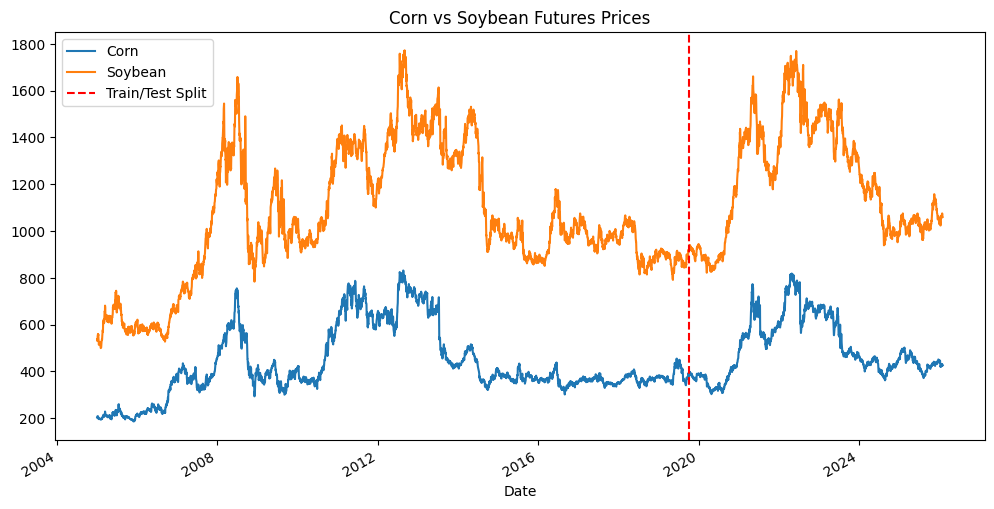

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint

df1=pd.read_csv(r'C:\Users\zezar\TilburgUniversity\Spring2026-TIC\data\daily_corn_prices.csv', skiprows=[1], index_col=0, parse_dates=True)
corn=df1['Close']

df2=pd.read_csv(r'C:\Users\zezar\TilburgUniversity\Spring2026-TIC\data\daily_soybean_prices.csv', skiprows=[1], index_col=0, parse_dates=True)
soybean=df2['Close']

df=pd.merge(left=corn, right=soybean, left_index=True, right_index=True, how='inner')
df.columns=['Corn', 'Soybean']

df_train=df.iloc[:int(len(df)*0.7)]
df_test=df.iloc[int(len(df)*0.7):]

plt.figure(figsize=(12, 6))

df['Corn'].plot(label='Corn')
df['Soybean'].plot(label='Soybean')

plt.axvline(x=df_train.index[-1], color='red', linestyle='--', label='Train/Test Split')
plt.title('Corn vs Soybean Futures Prices')
plt.legend()
plt.show()


In [2]:
adf_corn=adfuller(df_train['Corn'])
adf_soybean=adfuller(df_train['Soybean'])

print(f'ADF Statistic for Corn: {adf_corn[0]}')
print(f'p-value for Corn: {adf_corn[1]}')
print(f'ADF Statistic for Soybean: {adf_soybean[0]}')
print(f'p-value for Soybean: {adf_soybean[1]}')
print(f'Critical Values: {adf_soybean[4]}')

ADF Statistic for Corn: -2.0510748310015594
p-value for Corn: 0.2646369229222719
ADF Statistic for Soybean: -2.4232965313063146
p-value for Soybean: 0.1352687963790532
Critical Values: {'1%': -3.4321248463781306, '5%': -2.862324228723766, '10%': -2.5671874564323343}


In [3]:
corn_diff=df_train['Corn'].diff().dropna()
adf_corn_diff=adfuller(corn_diff)

soybean_diff=df_train['Soybean'].diff().dropna()
adf_soybean_diff=adfuller(soybean_diff)

print(f'ADF Statistic for Corn: {adf_corn_diff[0]}')
print(f'p-value for Corn: {adf_corn_diff[1]}')
print(f'ADF Statistic for Soybean: {adf_soybean_diff[0]}')
print(f'p-value for Soybean: {adf_soybean_diff[1]}')
print(f'Critical Values: {adf_soybean_diff[4]}')

ADF Statistic for Corn: -13.265508877822047
p-value for Corn: 8.234102570600015e-25
ADF Statistic for Soybean: -12.527458469047572
p-value for Soybean: 2.4705439183901883e-23
Critical Values: {'1%': -3.4321248463781306, '5%': -2.862324228723766, '10%': -2.5671874564323343}


                            OLS Regression Results                            
Dep. Variable:                Soybean   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                 1.294e+04
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        18:04:53   Log-Likelihood:                -23356.
No. Observations:                3712   AIC:                         4.672e+04
Df Residuals:                    3710   BIC:                         4.673e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        328.2656      6.598     49.756      0.0

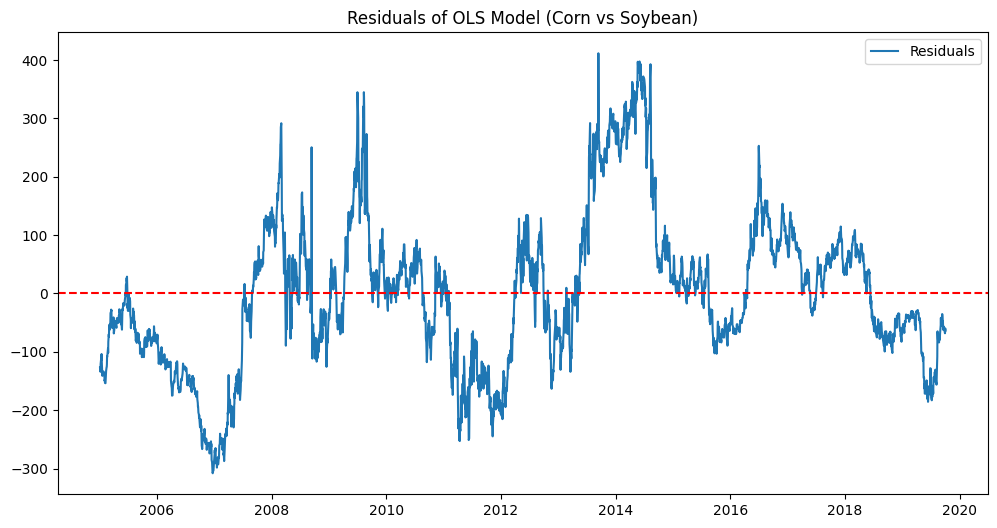

In [4]:
X_1=sm.add_constant(df_train['Corn'])
y_1=df_train['Soybean']
model_1=sm.OLS(y_1,X_1)
result_1=model_1.fit()
print(result_1.summary())

plt.figure(figsize=(12, 6))

plt.plot(result_1.resid, label='Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals of OLS Model (Corn vs Soybean)')
plt.legend()
plt.show()


In [5]:
adf_residuals_1=adfuller(result_1.resid, maxlag=1)
print(f'ADF Statistic for residuals: {adf_residuals_1[0]}')
print(f'p-value for residuals: {adf_residuals_1[1]}')
print(f'Critical Values: {adf_residuals_1[4]}')

ADF Statistic for residuals: -3.788970536148042
p-value for residuals: 0.003022198279214673
Critical Values: {'1%': -3.4321138356601963, '5%': -2.8623193649997063, '10%': -2.567184867154409}


In [6]:
X_2=sm.add_constant(df_train['Soybean'])
y_2=df_train['Corn']
model_2=sm.OLS(y_2,X_2)
result_2=model_2.fit()
print(result_2.summary())

adf_residuals_2=adfuller(result_2.resid, maxlag=1)
print(f'ADF Statistic for residuals: {adf_residuals_2[0]}')
print(f'p-value for residuals: {adf_residuals_2[1]}')
print(f'Critical Values: {adf_residuals_2[4]}')

                            OLS Regression Results                            
Dep. Variable:                   Corn   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                 1.294e+04
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        18:04:53   Log-Likelihood:                -20997.
No. Observations:                3712   AIC:                         4.200e+04
Df Residuals:                    3710   BIC:                         4.201e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -58.2693      4.409    -13.215      0.0

## CADF Test Results

We tested both variable orderings following Chan (2013) Example 2.6.

| Order | ADF Statistic | p-value | Conclusion |
|-------|--------------|---------|------------|
| Soybean = β*Corn + μ | -3.789 | 0.003 | Cointegrated |
| Corn = β*Soybean + μ | -3.696 | 0.004 | Cointegrated |

Both orderings confirm cointegration at the 95% confidence level.
We select **Order 1 (Soybean as dependent variable)** because it produces 
the more negative t-statistic (-3.789 vs -3.696), as recommended by the book.

The spread for the rest of the analysis is:
$$Spread = Soybean - 1.6645 \times Corn - 328.27$$

In [7]:
spread=result_1.resid
spread_diff=spread.diff().dropna()
spread_lagged=spread.shift(1).dropna()
spread_lagged=sm.add_constant(spread_lagged)
model_3=sm.OLS(spread_diff, spread_lagged)
result_3=model_3.fit()
print(result_3.summary())
lambda_val=result_3.params.iloc[1]
half_life=-np.log(2)/lambda_val
print(f"Half life :{half_life:.1f} days")


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     15.53
Date:                Mon, 11 May 2026   Prob (F-statistic):           8.28e-05
Time:                        18:04:53   Log-Likelihood:                -15703.
No. Observations:                3711   AIC:                         3.141e+04
Df Residuals:                    3709   BIC:                         3.142e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0172      0.273      0.063      0.9

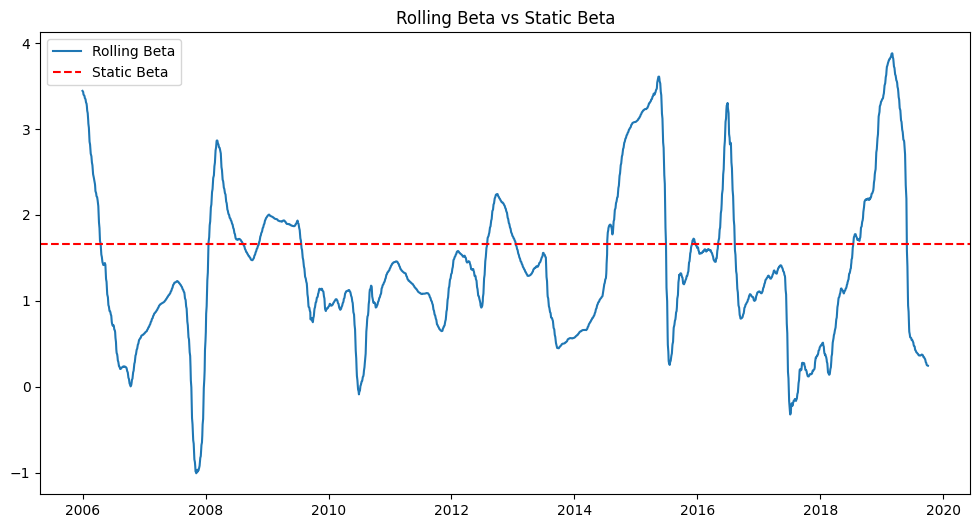

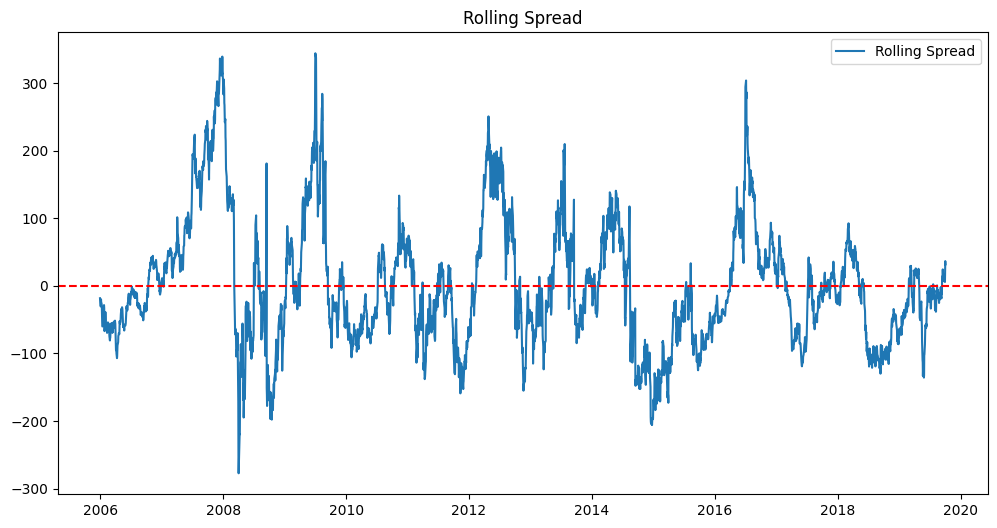

In [8]:
lookback=252
betas=np.full(len(df_train), np.nan)
mus=np.full(len(df_train), np.nan)
rolling_spread=np.full(len(df_train), np.nan)

for i in range(lookback, len(df_train)):
  corn_window=df_train['Corn'].iloc[i-lookback:i]
  soy_window=df_train['Soybean'].iloc[i-lookback:i]

  X_3=sm.add_constant(corn_window)
  y_3=soy_window
  model_4=sm.OLS(y_3, X_3)
  result_4=model_4.fit()
  betas[i]=result_4.params['Corn']
  mus[i]=result_4.params['const']
  rolling_spread[i]=result_4.resid.iloc[-1] 


plt.figure(figsize=(12,6))
plt.plot(df_train.index, betas, label='Rolling Beta')
plt.axhline(y=1.6645, color='red', linestyle='--', label='Static Beta')
plt.title('Rolling Beta vs Static Beta')
plt.legend()
plt.show()


plt.figure(figsize=(12,6))
plt.plot(df_train.index, rolling_spread, label='Rolling Spread')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Rolling Spread')
plt.legend()
plt.show()


{1.0: 0.5803074372545036, 1.5: 0.6793698780326943, 2.0: 0.5887333032332336, 2.5: 0.5264464410388645, 3.0: 0.552256676890828}
Best threshold: 1.5


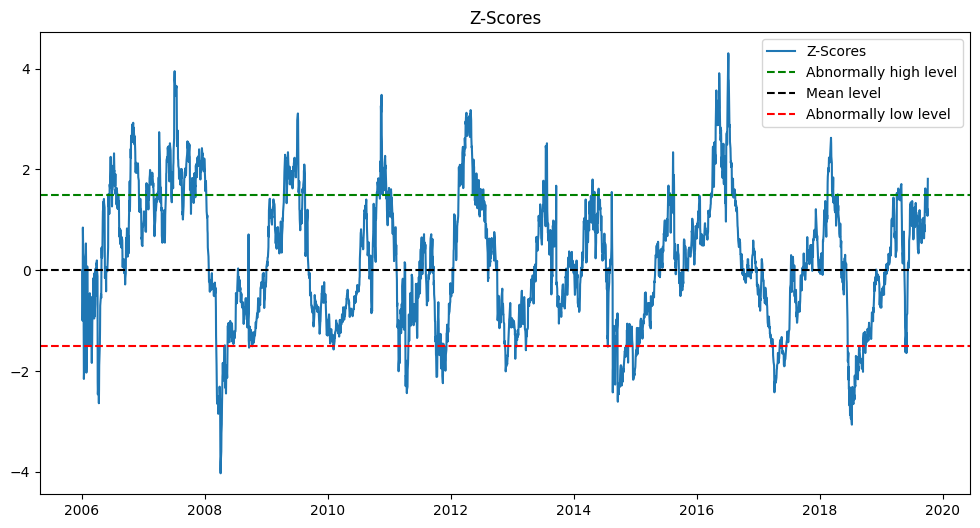

In [9]:
rolling_spread_series=pd.Series(rolling_spread, index=df_train.index)
z_scores=np.full(len(rolling_spread_series), np.nan)
for i in range(lookback, len(rolling_spread_series)):
  window_rolling_spread=rolling_spread_series.iloc[i-lookback:i]
  mean_rolling_spread=np.mean(window_rolling_spread)
  std_rolling_spread=np.std(window_rolling_spread)
  if std_rolling_spread == 0:
    z_scores[i] = 0
  else:
    z_scores[i] = (window_rolling_spread.iloc[-1] - mean_rolling_spread) / std_rolling_spread


thresholds = [1.0, 1.5, 2.0, 2.5, 3.0]
results = {}

for entry in thresholds:
    positions=np.zeros(len(z_scores))
    position=0

    for j in range(len(z_scores)):
      if np.isnan(z_scores[j]):
        position=0
      elif z_scores[j]>=entry:
        position=-1
      elif z_scores[j]<=-entry:
        position=1
      elif position==1 and z_scores[j]>=0:
        position=0
      elif position==-1 and z_scores[j]<=0:
        position=0
      positions[j]=position
    
    spread_changes=rolling_spread_series.diff()
    pnl=positions*spread_changes
    
    sharpe_ratio=np.mean(pnl)/np.std(pnl)*np.sqrt(252)

    results[entry]=sharpe_ratio
    
best_threshold = max(results, key=results.get)
print(results)
print(f'Best threshold: {best_threshold}')

plt.figure(figsize=(12,6))
plt.plot(df_train.index, z_scores, label='Z-Scores')
plt.axhline(y=best_threshold, color='green', linestyle='--', label='Abnormally high level')
plt.axhline(y=0, color='black', linestyle='--', label='Mean level')
plt.axhline(y=-best_threshold, color='red', linestyle='--', label='Abnormally low level')
plt.title('Z-Scores')
plt.legend()
plt.show()

## Parameter Optimization Results
Tested thresholds: 1.0, 1.5, 2.0, 2.5, 3.0
Optimal threshold on training data: **1.5**
Sharpe ratio: **0.679**
This threshold will be applied to the test set.

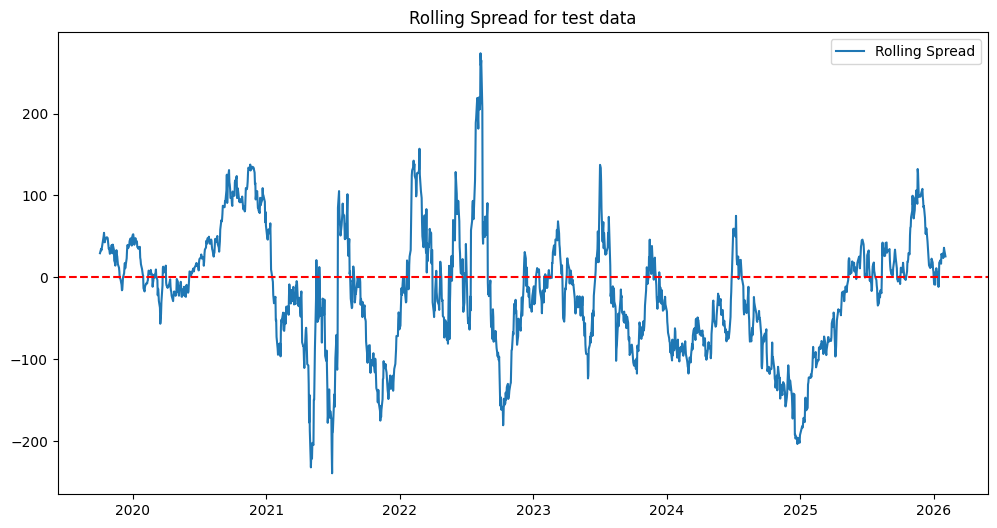

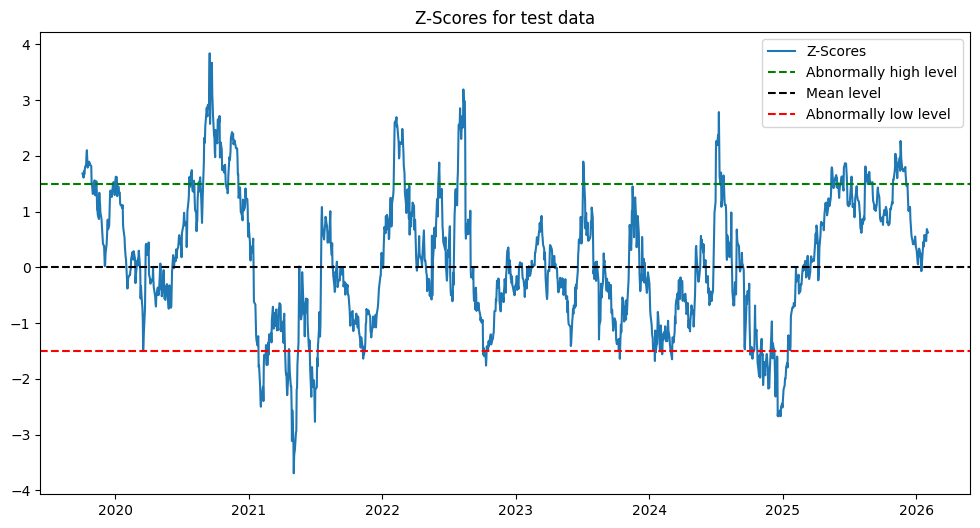

In [10]:
LOOKBACK=252
THRESHOLD=1.5

betas_final=np.full(len(df), np.nan)
spread_final=np.full(len(df), np.nan)

for i in range(LOOKBACK, len(df)):
  corn_window1=df['Corn'].iloc[i-LOOKBACK:i]
  soybean_window1=df['Soybean'].iloc[i-LOOKBACK:i]
  X_final=sm.add_constant(corn_window1)
  y_final=soybean_window1
  model_final=sm.OLS(y_final, X_final)
  result_final=model_final.fit()

  betas_final[i]=result_final.params['Corn']
  spread_final[i]=result_final.resid.iloc[-1]

spread_final_series=pd.Series(spread_final, index=df.index)
z_scores_final=np.full(len(spread_final_series), np.nan)

for j in range(LOOKBACK, len(df)):
  window_spread_final=spread_final_series.iloc[j-LOOKBACK:j]
  mean_spread_final=np.mean(window_spread_final)
  std_spread_final=np.std(window_spread_final)
  if std_spread_final==0:
    z_scores_final[j]=0
  else:
    z_scores_final[j]=(window_spread_final.iloc[-1]-mean_spread_final)/std_spread_final

z_scores_final_series=pd.Series(z_scores_final, index=df.index)
z_scores_test= z_scores_final_series[df.index>=df_test.index[0]]
spread_test = spread_final_series[df.index >= df_test.index[0]]

plt.figure(figsize=(12,6))
plt.plot(df_test.index, spread_test, label='Rolling Spread')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Rolling Spread for test data')
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df_test.index, z_scores_test, label='Z-Scores')
plt.axhline(y=best_threshold, color='green', linestyle='--', label='Abnormally high level')
plt.axhline(y=0, color='black', linestyle='--', label='Mean level')
plt.axhline(y=-best_threshold, color='red', linestyle='--', label='Abnormally low level')
plt.title('Z-Scores for test data')
plt.legend()
plt.show()

Sharpe Ratio:   0.071
Total Return:   1.40%
Max Drawdown:   -39.64%
Total P&L (pts): 459.79


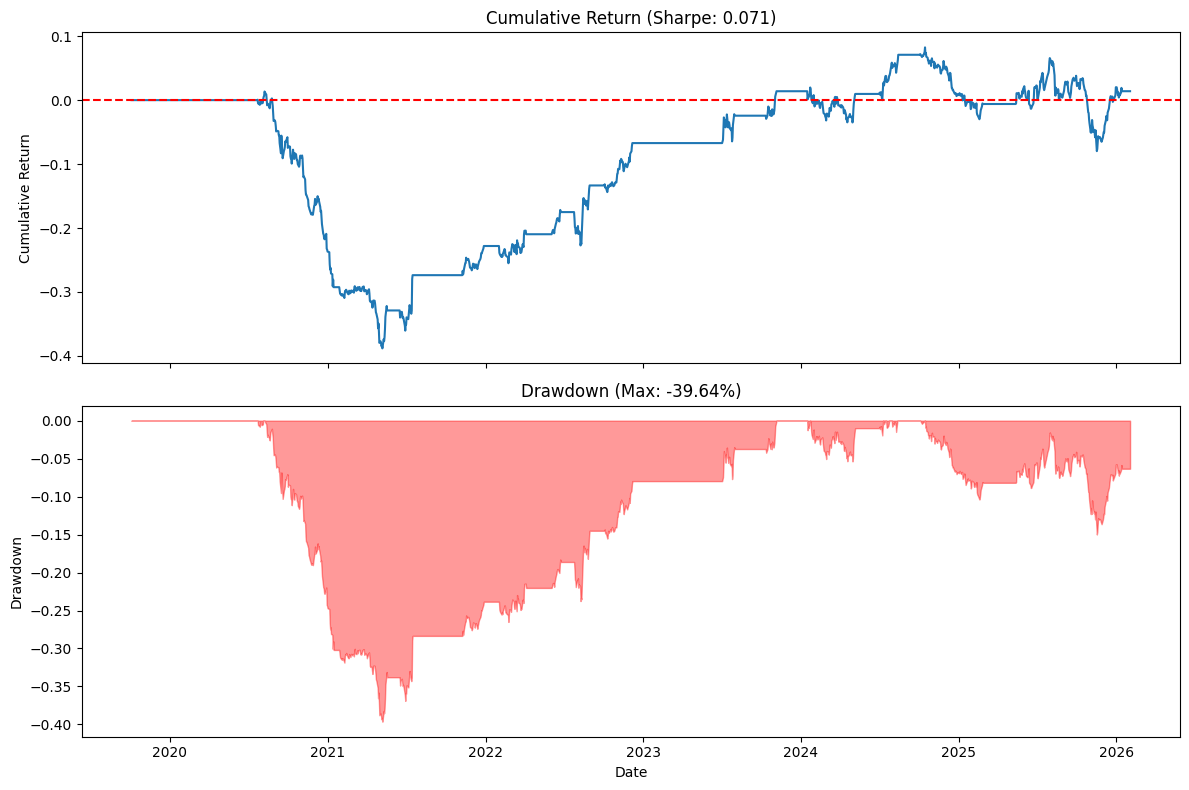

In [11]:
positions_final=np.zeros(len(z_scores_test))
position_final=0
for i in range(len(z_scores_test)):
  if np.isnan(z_scores_test.iloc[i]):
    position_final = 0
  elif z_scores_test.iloc[i] >= THRESHOLD:
    position_final = -1
  elif z_scores_test.iloc[i] <= -THRESHOLD:
    position_final = 1
  elif position_final == 1 and z_scores_test.iloc[i] >= 0:
    position_final = 0
  elif position_final == -1 and z_scores_test.iloc[i] <= 0:
    position_final = 0
  positions_final[i] = position_final

split = int(len(df) * 0.7)
betas_test  = betas_final[split:]
soy_test    = df_test['Soybean'].values
corn_test   = df_test['Corn'].values
delta_soy   = df_test['Soybean'].diff().values
delta_corn  = df_test['Corn'].diff().values

pnl_fixed   = np.zeros(len(positions_final))
returns      = np.zeros(len(positions_final))
beta_entry   = np.nan
capital_entry = np.nan

for i in range(1, len(positions_final)):
    prev_pos = positions_final[i - 1]
    curr_pos = positions_final[i]

    if prev_pos == 0 and curr_pos != 0:
        beta_entry = betas_test[i]
        capital_entry = soy_test[i-1] + abs(beta_entry) * corn_test[i-1]

    if curr_pos != 0 and not np.isnan(beta_entry):
        pnl_fixed[i] = curr_pos * (delta_soy[i] - beta_entry * delta_corn[i])
        returns[i]   = pnl_fixed[i] / capital_entry
    else:
        pnl_fixed[i] = 0.0
        returns[i]   = 0.0

    if curr_pos == 0:
        beta_entry = np.nan
        capital_entry = np.nan

returns = pd.Series(returns, index=df_test.index)
pnl_fixed = pd.Series(pnl_fixed, index=df_test.index)

sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252) if np.std(returns) > 0 else 0
cum_ret = (1 + returns).cumprod() - 1
total_ret = cum_ret.iloc[-1]
rolling_max = (1 + returns).cumprod().cummax()
drawdown = (1 + returns).cumprod() / rolling_max - 1
max_dd = drawdown.min()

print(f'Sharpe Ratio:   {sharpe:.3f}')
print(f'Total Return:   {total_ret:.2%}')
print(f'Max Drawdown:   {max_dd:.2%}')
print(f'Total P&L (pts): {pnl_fixed.sum():.2f}')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(cum_ret.index, cum_ret.values)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'Cumulative Return (Sharpe: {sharpe:.3f})')
axes[0].set_ylabel('Cumulative Return')

axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.4, color='red')
axes[1].set_title(f'Drawdown (Max: {max_dd:.2%})')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

## Johansen Test on Four Commodities

We now extend the analysis from a pair to four commodities (Corn, Soybean, Wheat, Cotton) using the Johansen test following Chan (2013) Example 2.7.

The Johansen test is preferred over CADF for multiple series because it is order-independent and provides hedge ratios directly through its eigenvectors.

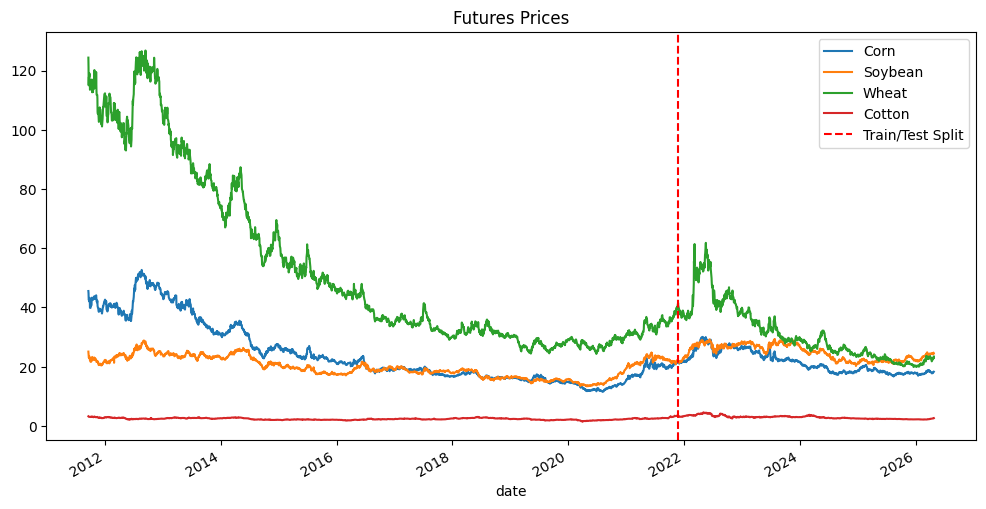

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen

df1=pd.read_csv(r'C:\Users\zezar\TilburgUniversity\Spring2026-TIC\Ensemble_Wiktor\data\merged_corn_soybean_wheat_cotton.csv', skiprows=[1], index_col=0, parse_dates=True)
corn=df1['close_corn']
soybean=df1['close_soybean']
wheat=df1['close_wheat']
cotton=df1['close_cotton']

df=pd.concat([corn, soybean, wheat, cotton], axis=1)
df.columns=['Corn', 'Soybean', 'Wheat', 'Cotton']

df_train=df.iloc[:int(len(df)*0.7)]
df_test=df.iloc[int(len(df)*0.7):]

plt.figure(figsize=(12, 6))

df['Corn'].plot(label='Corn')
df['Soybean'].plot(label='Soybean')
df['Wheat'].plot(label='Wheat')
df['Cotton'].plot(label='Cotton')

plt.axvline(x=df_train.index[-1], color='red', linestyle='--', label='Train/Test Split')
plt.title('Futures Prices')
plt.legend()
plt.show()

In [13]:
adf_corn=adfuller(df_train['Corn'])
adf_soybean=adfuller(df_train['Soybean'])
adf_wheat=adfuller(df_train['Wheat'])
adf_cotton=adfuller(df_train['Cotton'])

print(f'ADF Statistic for Corn: {adf_corn[0]}')
print(f'p-value for Corn: {adf_corn[1]}')
print(f'ADF Statistic for Soybean: {adf_soybean[0]}')
print(f'p-value for Soybean: {adf_soybean[1]}')
print(f'ADF Statistic for Wheat: {adf_wheat[0]}')
print(f'p-value for Wheat: {adf_wheat[1]}')
print(f'ADF Statistic for Cotton: {adf_cotton[0]}')
print(f'p-value for Cotton: {adf_cotton[1]}')
print(f'Critical Values: {adf_soybean[4]}')

ADF Statistic for Corn: -1.9416474883191506
p-value for Corn: 0.31272943996111335
ADF Statistic for Soybean: -1.8500507300892937
p-value for Soybean: 0.3559109696697546
ADF Statistic for Wheat: -2.2212542264301733
p-value for Wheat: 0.19862202636181386
ADF Statistic for Cotton: -2.301365976236572
p-value for Cotton: 0.17152779547395824
Critical Values: {'1%': -3.4329476085791493, '5%': -2.8626876136761292, '10%': -2.5673809185248175}


In [14]:
corn_diff=df_train['Corn'].diff().dropna()
adf_corn_diff=adfuller(corn_diff)

soybean_diff=df_train['Soybean'].diff().dropna()
adf_soybean_diff=adfuller(soybean_diff)

wheat_diff=df_train['Wheat'].diff().dropna()
adf_wheat_diff=adfuller(wheat_diff)

cotton_diff=df_train['Cotton'].diff().dropna()
adf_cotton_diff=adfuller(cotton_diff)

print(f'ADF Statistic for Corn: {adf_corn_diff[0]}')
print(f'p-value for Corn: {adf_corn_diff[1]}')
print(f'ADF Statistic for Soybean: {adf_soybean_diff[0]}')
print(f'p-value for Soybean: {adf_soybean_diff[1]}')
print(f'ADF Statistic for Wheat: {adf_wheat_diff[0]}')
print(f'p-value for Wheat: {adf_wheat_diff[1]}')
print(f'ADF Statistic for Cotton: {adf_cotton_diff[0]}')
print(f'p-value for Cotton: {adf_cotton_diff[1]}')
print(f'Critical Values: {adf_soybean_diff[4]}')

ADF Statistic for Corn: -9.171156001601226
p-value for Corn: 2.38636435725362e-15
ADF Statistic for Soybean: -56.092950108524676
p-value for Soybean: 0.0
ADF Statistic for Wheat: -11.396413869426183
p-value for Wheat: 7.838538580427442e-21
ADF Statistic for Cotton: -51.93705238817174
p-value for Cotton: 0.0
Critical Values: {'1%': -3.4329476085791493, '5%': -2.8626876136761292, '10%': -2.5673809185248175}


In [15]:
result = coint_johansen(df_train, det_order=0, k_ar_diff=1)

print('Trace Statistics:')
print(result.lr1)
print('Critical values 90%, 95%, 99%:')
print(result.cvt)

print('\nEigen Statistics:')
print(result.lr2)
print('Critical values 90%, 95%, 99%:')
print(result.cvm)

print('\nEigenvalues:')
print(result.eig)

print('\nEigenvectors:')
print(result.evec)

Trace Statistics:
[47.78175715 21.35414727  8.48468702  3.00483256]
Critical values 90%, 95%, 99%:
[[44.4929 47.8545 54.6815]
 [27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]

Eigen Statistics:
[26.42760988 12.86946025  5.47985446  3.00483256]
Critical values 90%, 95%, 99%:
[[25.1236 27.5858 32.7172]
 [18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]

Eigenvalues:
[0.01043235 0.00509391 0.00217218 0.00119168]

Eigenvectors:
[[ 6.76437166e-01  3.04093442e-01 -3.83718935e-03 -9.97629375e-02]
 [-1.22725607e-01 -5.47321532e-01 -2.70188913e-01  1.39301467e-01]
 [-2.25656548e-01 -5.38831476e-02  6.67841945e-04 -6.41801200e-03]
 [-8.60134947e-01  2.43572031e+00 -3.50002014e-01  2.77488660e+00]]


In [16]:
hedge_ratios = result.evec[:, 0]
print(f'Corn:    {hedge_ratios[0]:.4f}')
print(f'Soybean: {hedge_ratios[1]:.4f}')
print(f'Wheat:   {hedge_ratios[2]:.4f}')
print(f'Cotton:  {hedge_ratios[3]:.4f}')

Corn:    0.6764
Soybean: -0.1227
Wheat:   -0.2257
Cotton:  -0.8601


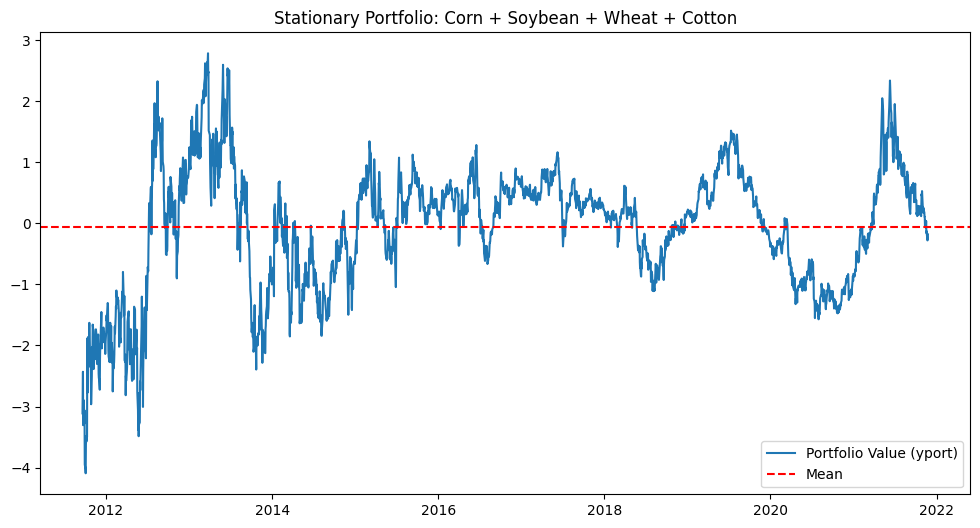


ADF Statistic: -4.8797
p-value: 0.0000
Critical Values: {'1%': -3.4329476085791493, '5%': -2.8626876136761292, '10%': -2.5673809185248175}


In [17]:
yport = (df_train * hedge_ratios).sum(axis=1)

plt.figure(figsize=(12, 6))
plt.plot(yport.index, yport.values, label='Portfolio Value (yport)')
plt.axhline(yport.mean(), color='red', linestyle='--', label='Mean')
plt.title('Stationary Portfolio: Corn + Soybean + Wheat + Cotton')
plt.legend()
plt.show()

adf_yport = adfuller(yport, maxlag=1, autolag=None)
print(f'\nADF Statistic: {adf_yport[0]:.4f}')
print(f'p-value: {adf_yport[1]:.4f}')
print(f'Critical Values: {adf_yport[4]}')

In [18]:
yport_diff = yport.diff().dropna()
yport_lagged = yport.shift(1).dropna()
yport_lagged = sm.add_constant(yport_lagged)
model_hl = sm.OLS(yport_diff, yport_lagged)
result_hl = model_hl.fit()
lambda_val = result_hl.params.iloc[1]  
half_life = -np.log(2) / lambda_val
print(f'Half life: {half_life:.1f} days')

Half life: 33.4 days


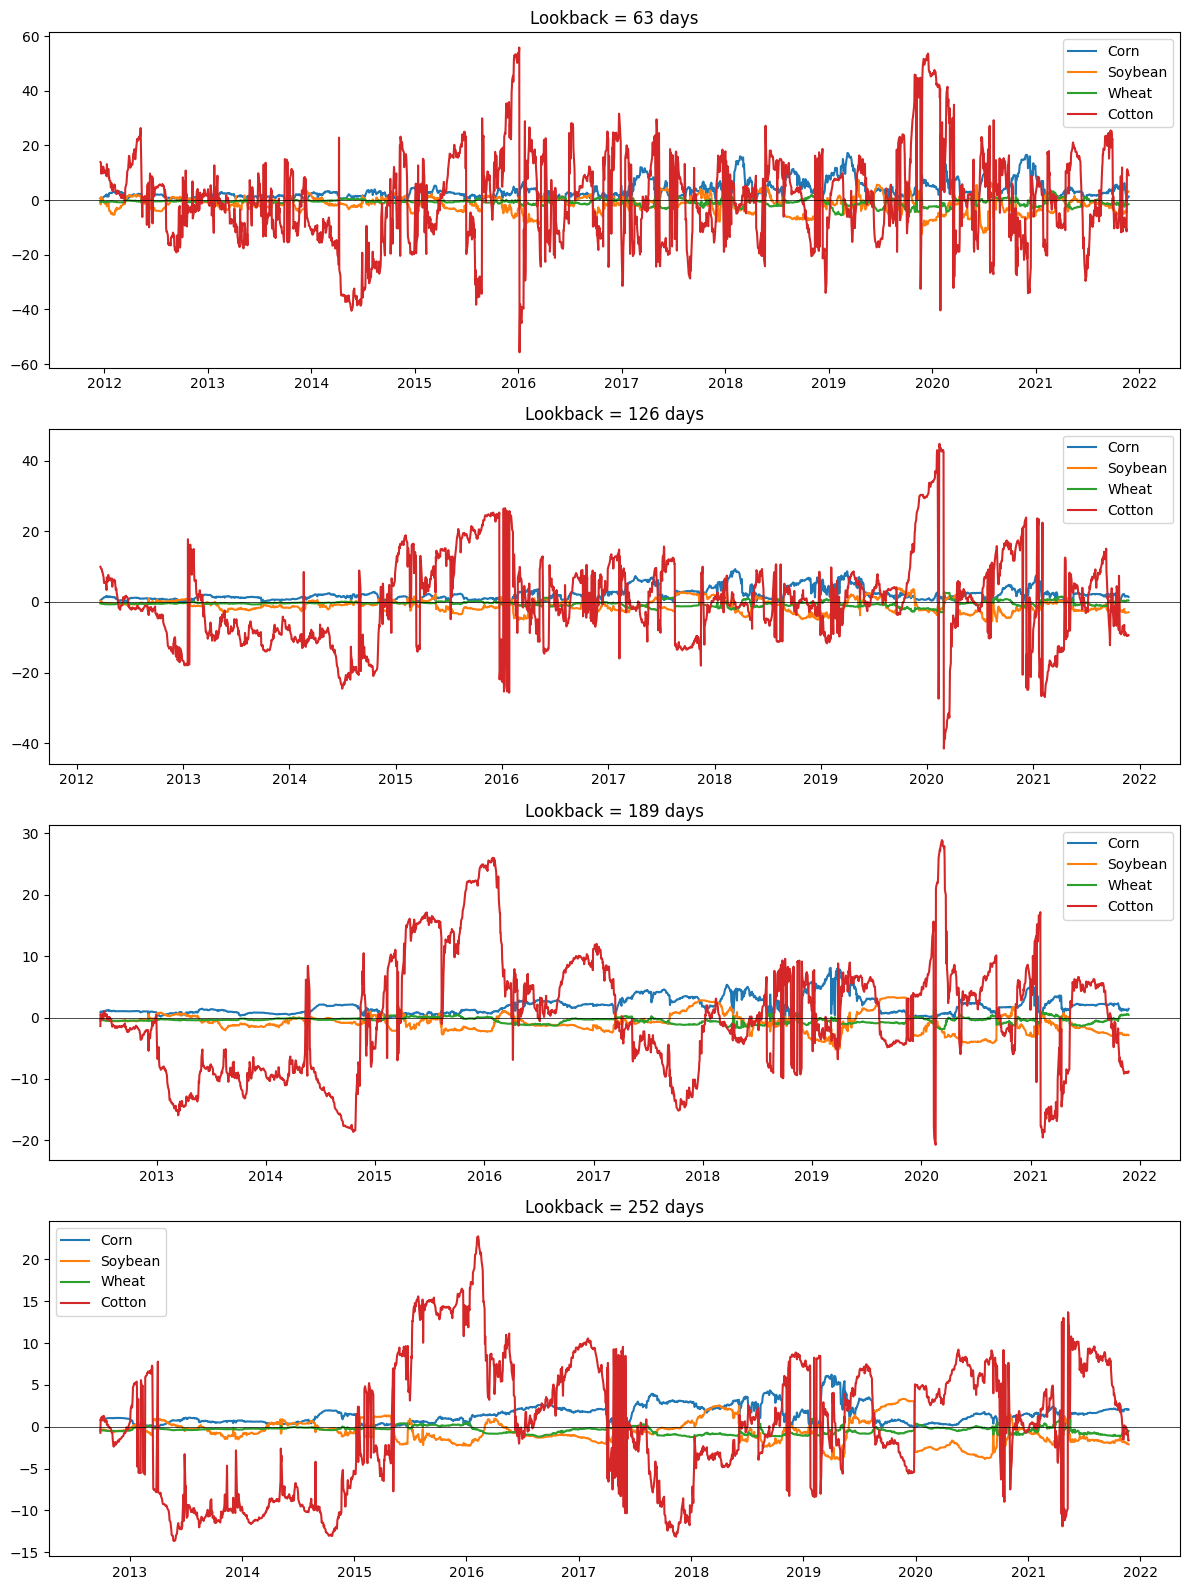

In [19]:
def rolling_eigenvectors(df_train, lookback):
    n_assets = df_train.shape[1]
    eigenvectors = np.full((len(df_train), n_assets), np.nan)
    
    for i in range(lookback, len(df_train)):
        window = df_train.iloc[i-lookback:i]
        try:
            result = coint_johansen(window, det_order=0, k_ar_diff=1)
            eigenvectors[i] = result.evec[:, 0]
        except:
            pass
    
    return pd.DataFrame(eigenvectors, index=df_train.index, columns=df_train.columns)

fig, axes = plt.subplots(4, 1, figsize=(12, 16))
for ax, lb in zip(axes, [63, 126, 189, 252]):
    eigvec = rolling_eigenvectors(df_train, lb)
    for col in eigvec.columns:
        ax.plot(eigvec.index, eigvec[col], label=col)
    ax.set_title(f'Lookback = {lb} days')
    ax.legend()
    ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

{1.0: 1.5628772687619854, 1.5: 1.499871995954633, 2.0: 1.2050514749485686, 2.5: 0.8974037533470566, 3.0: 0.434593210129421}
Best threshold: 1.0


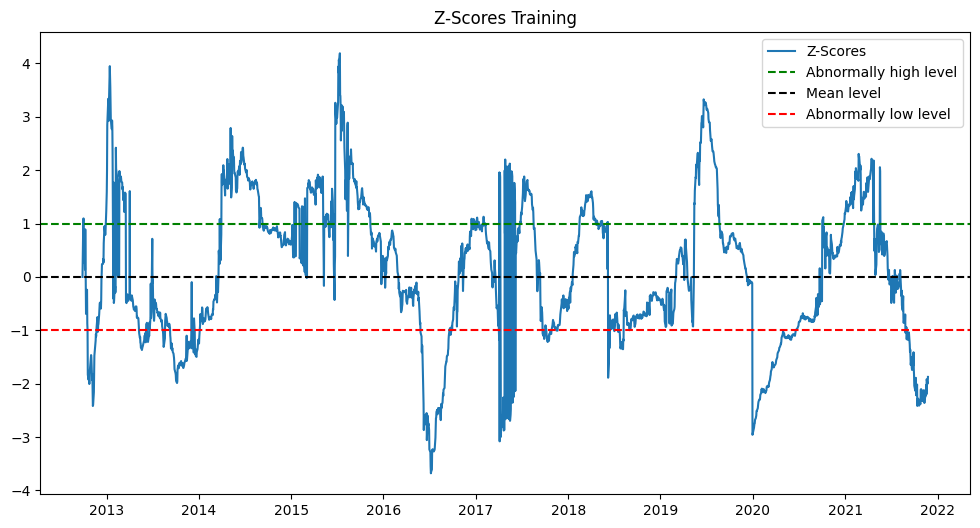

In [20]:
LOOKBACK = 252
hedge_train = np.full((len(df_train), 4), np.nan)
rolling_spread = np.full(len(df_train), np.nan)

for i in range(LOOKBACK, len(df_train)):
    window = df_train.iloc[i-LOOKBACK:i]
    result_window = coint_johansen(window, det_order=0, k_ar_diff=1)
    hedge_train[i] = result_window.evec[:, 0]
    rolling_spread[i] = (df_train.iloc[i].values * result_window.evec[:, 0]).sum()

rolling_spread_series = pd.Series(rolling_spread, index=df_train.index)

z_scores = np.full(len(rolling_spread_series), np.nan)
for i in range(LOOKBACK, len(rolling_spread_series)):
    window_rolling_spread = rolling_spread_series.iloc[i-LOOKBACK:i]
    mean_rolling_spread = np.mean(window_rolling_spread)
    std_rolling_spread = np.std(window_rolling_spread)
    if std_rolling_spread == 0:
        z_scores[i] = 0
    else:
        z_scores[i] = (window_rolling_spread.iloc[-1] - mean_rolling_spread) / std_rolling_spread

thresholds = [1.0, 1.5, 2.0, 2.5, 3.0]
results = {}

for entry in thresholds:
    positions = np.zeros(len(z_scores))
    position = 0
    for j in range(len(z_scores)):
        if np.isnan(z_scores[j]):
            position = 0
        elif z_scores[j] >= entry:
            position = -1
        elif z_scores[j] <= -entry:
            position = 1
        elif position == 1 and z_scores[j] >= 0:
            position = 0
        elif position == -1 and z_scores[j] <= 0:
            position = 0
        positions[j] = position
    
    spread_changes = rolling_spread_series.diff()
    pnl = positions * spread_changes
    sharpe_ratio = np.mean(pnl) / np.std(pnl) * np.sqrt(252)
    results[entry] = sharpe_ratio

best_threshold = max(results, key=results.get)
print(results)
print(f'Best threshold: {best_threshold}')

plt.figure(figsize=(12,6))
plt.plot(df_train.index, z_scores, label='Z-Scores')
plt.axhline(y=best_threshold, color='green', linestyle='--', label='Abnormally high level')
plt.axhline(y=0, color='black', linestyle='--', label='Mean level')
plt.axhline(y=-best_threshold, color='red', linestyle='--', label='Abnormally low level')
plt.title('Z-Scores Training')
plt.legend()
plt.show()

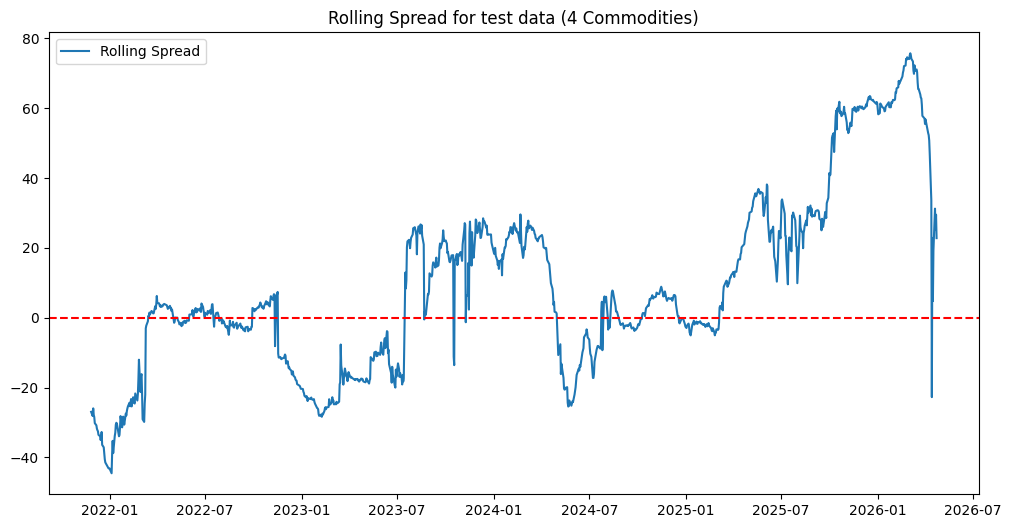

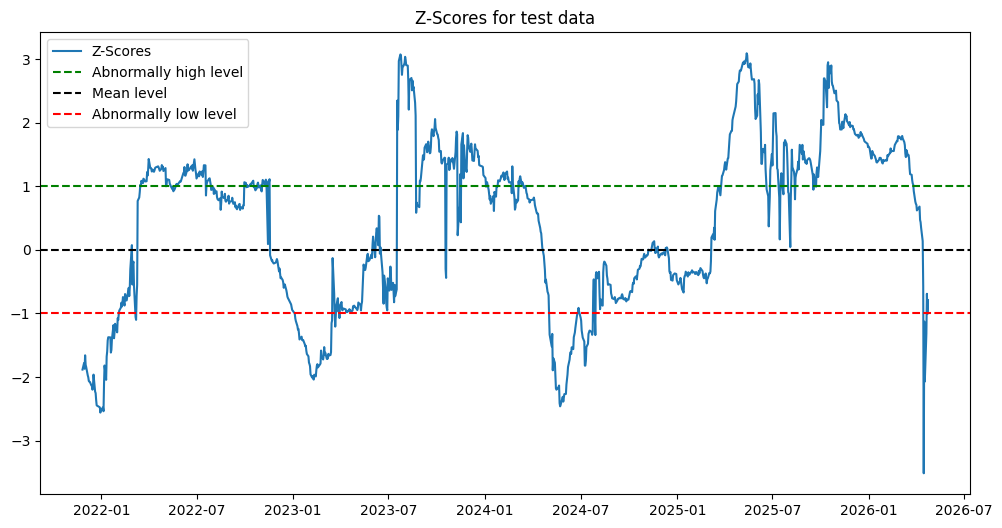

In [21]:
hedge_final = np.full((len(df), 4), np.nan)
spread_final = np.full(len(df), np.nan)

for i in range(LOOKBACK, len(df)):
    window = df.iloc[i-LOOKBACK:i]
    result_window = coint_johansen(window, det_order=0, k_ar_diff=1)
    hedge_final[i] = result_window.evec[:, 0]
    spread_final[i] = (df.iloc[i].values * result_window.evec[:, 0]).sum()

spread_final_series = pd.Series(spread_final, index=df.index)
hedge_final_df = pd.DataFrame(hedge_final, index=df.index, columns=['Corn', 'Soybean', 'Wheat', 'Cotton'])

z_scores_final = np.full(len(spread_final_series), np.nan)
for j in range(LOOKBACK, len(df)):
    window_spread_final = spread_final_series.iloc[j-LOOKBACK:j]
    mean_spread_final = np.mean(window_spread_final)
    std_spread_final = np.std(window_spread_final)
    if std_spread_final == 0:
        z_scores_final[j] = 0
    else:
        z_scores_final[j] = (window_spread_final.iloc[-1] - mean_spread_final) / std_spread_final

z_scores_final_series = pd.Series(z_scores_final, index=df.index)

z_scores_test = z_scores_final_series[df.index >= df_test.index[0]]
spread_test = spread_final_series[df.index >= df_test.index[0]]

plt.figure(figsize=(12,6))
plt.plot(df_test.index, spread_test, label='Rolling Spread')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Rolling Spread for test data (4 Commodities)')
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df_test.index, z_scores_test, label='Z-Scores')
plt.axhline(y=best_threshold, color='green', linestyle='--', label='Abnormally high level')
plt.axhline(y=0, color='black', linestyle='--', label='Mean level')
plt.axhline(y=-best_threshold, color='red', linestyle='--', label='Abnormally low level')
plt.title('Z-Scores for test data')
plt.legend()
plt.show()

Sharpe Ratio:   -0.007
Total Return:   -1.74%
Max Drawdown:   -17.45%
Total P&L:      -0.89


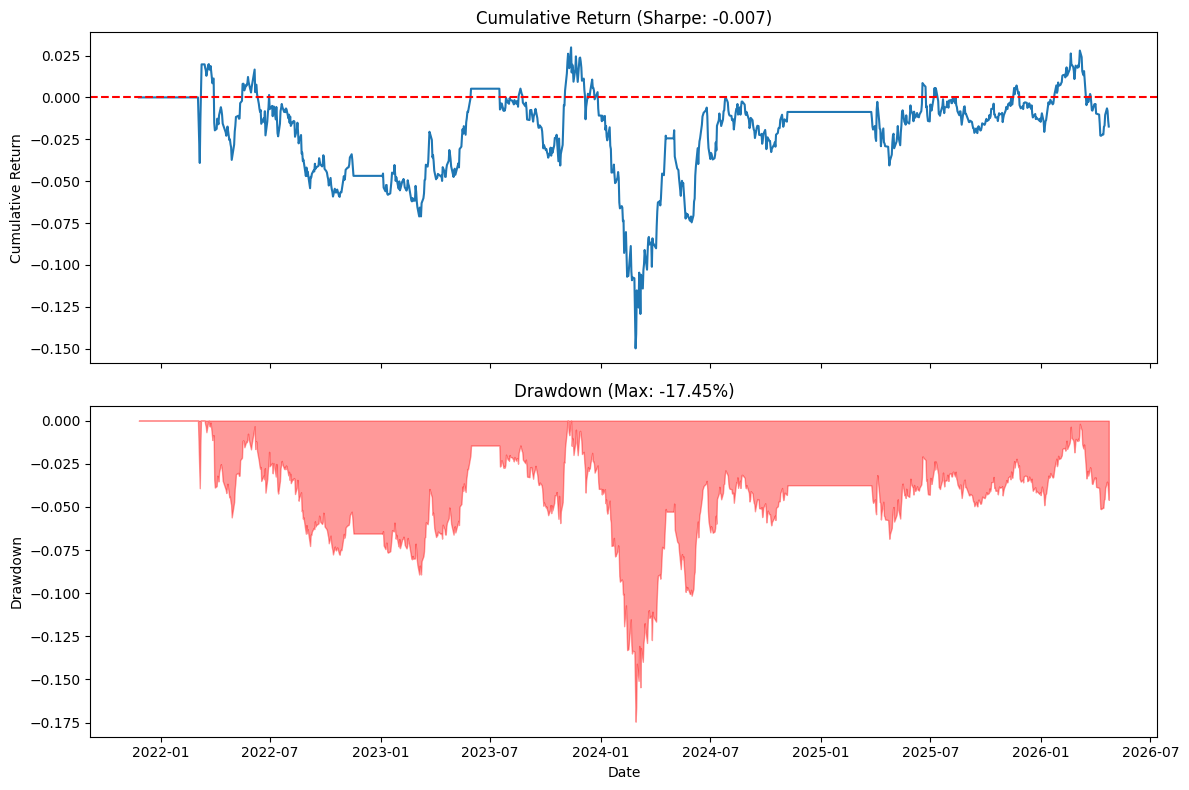

In [22]:
THRESHOLD = best_threshold

positions_final = np.zeros(len(z_scores_test))
position_final = 0
for i in range(len(z_scores_test)):
    if np.isnan(z_scores_test.iloc[i]):
        position_final = 0
    elif z_scores_test.iloc[i] >= THRESHOLD:
        position_final = -1
    elif z_scores_test.iloc[i] <= -THRESHOLD:
        position_final = 1
    elif position_final == 1 and z_scores_test.iloc[i] >= 0:
        position_final = 0
    elif position_final == -1 and z_scores_test.iloc[i] <= 0:
        position_final = 0
    positions_final[i] = position_final

split = int(len(df) * 0.7)
hedge_test = hedge_final[split:]
corn_test = df_test['Corn'].values
soy_test = df_test['Soybean'].values
wheat_test = df_test['Wheat'].values
cotton_test = df_test['Cotton'].values
delta_corn = df_test['Corn'].diff().values
delta_soy = df_test['Soybean'].diff().values
delta_wheat = df_test['Wheat'].diff().values
delta_cotton =  df_test['Cotton'].diff().values

pnl_fixed = np.zeros(len(positions_final))
returns = np.zeros(len(positions_final))
hedge_entry = None
capital_entry = np.nan

for i in range(1, len(positions_final)):
    prev_pos = positions_final[i-1]
    curr_pos = positions_final[i]
    
    if prev_pos == 0 and curr_pos != 0:
        hedge_entry = hedge_test[i]
        capital_entry = (abs(hedge_entry[0]) * corn_test[i-1] + abs(hedge_entry[1]) * soy_test[i-1] + abs(hedge_entry[2]) * wheat_test[i-1] + abs(hedge_entry[3]) * cotton_test[i-1])
    
    if curr_pos != 0 and hedge_entry is not None:
        pnl_fixed[i] = curr_pos * (hedge_entry[0] * delta_corn[i] + hedge_entry[1] * delta_soy[i] + hedge_entry[2] * delta_wheat[i] + hedge_entry[3]*delta_cotton[i])
        returns[i] = pnl_fixed[i] / capital_entry
    else:
        pnl_fixed[i] = 0.0
        returns[i] = 0.0
    
    if curr_pos == 0:
        hedge_entry = None
        capital_entry = np.nan

returns = pd.Series(returns, index=df_test.index)
pnl_fixed = pd.Series(pnl_fixed, index=df_test.index)

sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252) if np.std(returns) > 0 else 0
cum_ret = (1 + returns).cumprod() - 1
total_ret = cum_ret.iloc[-1]
rolling_max = (1 + returns).cumprod().cummax()
drawdown = (1 + returns).cumprod() / rolling_max - 1
max_dd = drawdown.min()

print(f'Sharpe Ratio:   {sharpe:.3f}')
print(f'Total Return:   {total_ret:.2%}')
print(f'Max Drawdown:   {max_dd:.2%}')
print(f'Total P&L:      {pnl_fixed.sum():.2f}')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(cum_ret.index, cum_ret.values)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'Cumulative Return (Sharpe: {sharpe:.3f})')
axes[0].set_ylabel('Cumulative Return')

axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.4, color='red')
axes[1].set_title(f'Drawdown (Max: {max_dd:.2%})')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

## Three-Asset Combinations

After observing that adding cotton weakens the cointegration result in the four-asset case, we now test all four possible combinations of three commodities to identify which subset gives the most reliable and tradeable mean-reverting portfolio.

**Combinations tested:**
1. Corn + Soybean + Wheat
2. Corn + Soybean + Cotton
3. Corn + Wheat + Cotton
4. Soybean + Wheat + Cotton

### Combination 1: Corn + Soybean + Wheat

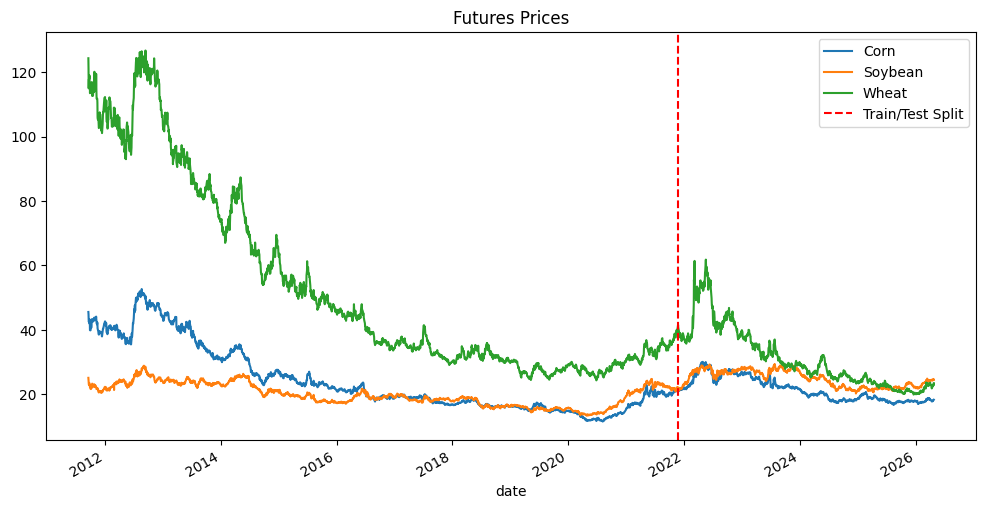

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen

df1=pd.read_csv(r'C:\Users\zezar\TilburgUniversity\Spring2026-TIC\Ensemble_Wiktor\data\merged_corn_soybean_wheat_cotton.csv', skiprows=[1], index_col=0, parse_dates=True)
corn=df1['close_corn']
soybean=df1['close_soybean']
wheat=df1['close_wheat']


df=pd.concat([corn, soybean, wheat], axis=1)
df.columns=['Corn', 'Soybean', 'Wheat']

df_train=df.iloc[:int(len(df)*0.7)]
df_test=df.iloc[int(len(df)*0.7):]

plt.figure(figsize=(12, 6))

df['Corn'].plot(label='Corn')
df['Soybean'].plot(label='Soybean')
df['Wheat'].plot(label='Wheat')

plt.axvline(x=df_train.index[-1], color='red', linestyle='--', label='Train/Test Split')
plt.title('Futures Prices')
plt.legend()
plt.show()

In [24]:
result = coint_johansen(df_train, det_order=0, k_ar_diff=1)

print('Trace Statistics:')
print(result.lr1)
print('Critical values 90%, 95%, 99%:')
print(result.cvt)

print('\nEigen Statistics:')
print(result.lr2)
print('Critical values 90%, 95%, 99%:')
print(result.cvm)

print('\nEigenvalues:')
print(result.eig)

print('\nEigenvectors:')
print(result.evec)

Trace Statistics:
[33.57808738 10.43166542  4.72795059]
Critical values 90%, 95%, 99%:
[[27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]

Eigen Statistics:
[23.14642196  5.70371483  4.72795059]
Critical values 90%, 95%, 99%:
[[18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]

Eigenvalues:
[0.00914303 0.00226082 0.00187441]

Eigenvectors:
[[ 0.73538783 -0.1095018   0.07823032]
 [-0.29346612  0.10974514 -0.51983884]
 [-0.23103077 -0.00591872  0.01662791]]


In [25]:
hedge_ratios = result.evec[:, 0]
print(f'Corn:    {hedge_ratios[0]:.4f}')
print(f'Soybean: {hedge_ratios[1]:.4f}')
print(f'Wheat:   {hedge_ratios[2]:.4f}')

Corn:    0.7354
Soybean: -0.2935
Wheat:   -0.2310


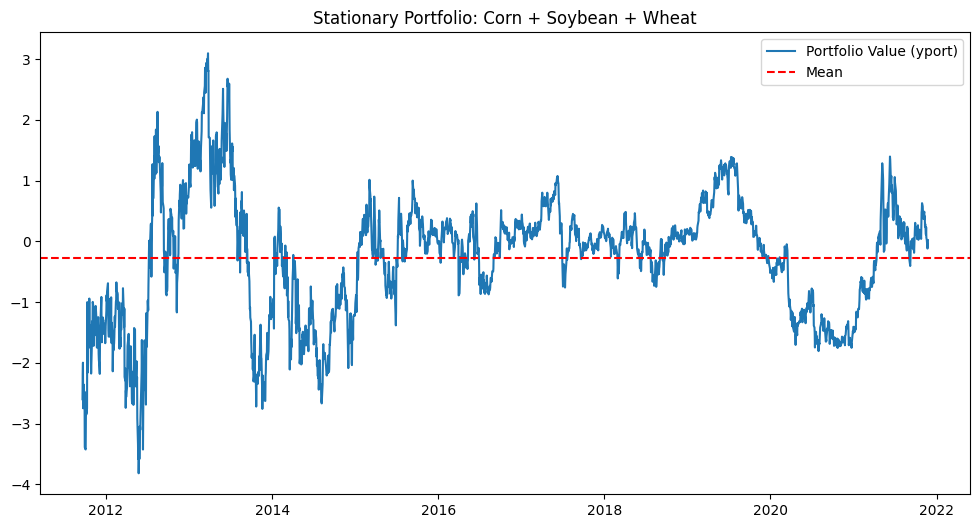


ADF Statistic: -4.8145
p-value: 0.0001
Critical Values: {'1%': -3.4329476085791493, '5%': -2.8626876136761292, '10%': -2.5673809185248175}


In [26]:
yport = (df_train * hedge_ratios).sum(axis=1)

plt.figure(figsize=(12, 6))
plt.plot(yport.index, yport.values, label='Portfolio Value (yport)')
plt.axhline(yport.mean(), color='red', linestyle='--', label='Mean')
plt.title('Stationary Portfolio: Corn + Soybean + Wheat')
plt.legend()
plt.show()

adf_yport = adfuller(yport, maxlag=1, autolag=None)
print(f'\nADF Statistic: {adf_yport[0]:.4f}')
print(f'p-value: {adf_yport[1]:.4f}')
print(f'Critical Values: {adf_yport[4]}')

In [27]:
yport_diff = yport.diff().dropna()
yport_lagged = yport.shift(1).dropna()
yport_lagged = sm.add_constant(yport_lagged)
model_hl = sm.OLS(yport_diff, yport_lagged)
result_hl = model_hl.fit()
lambda_val = result_hl.params.iloc[1]  
half_life = -np.log(2) / lambda_val
print(f'Half life: {half_life:.1f} days')

Half life: 31.9 days


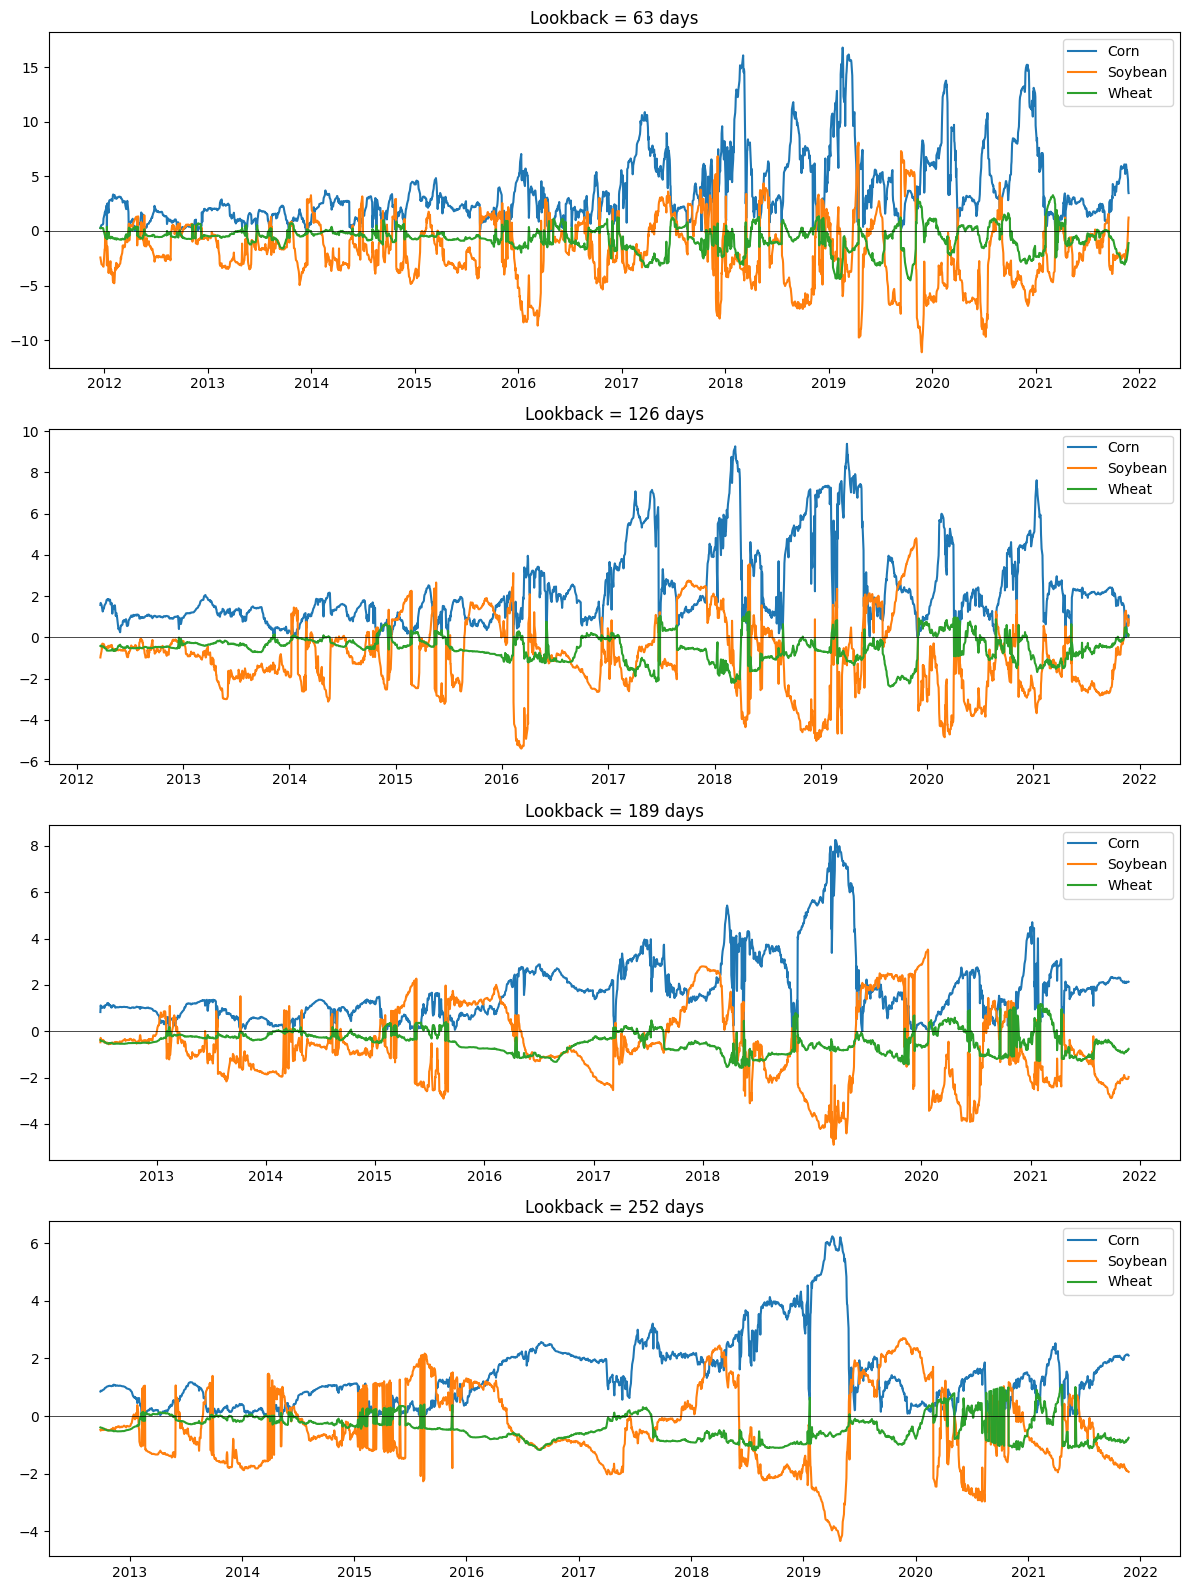

In [28]:
def rolling_eigenvectors(df_train, lookback):
    n_assets = df_train.shape[1]
    eigenvectors = np.full((len(df_train), n_assets), np.nan)
    
    for i in range(lookback, len(df_train)):
        window = df_train.iloc[i-lookback:i]
        try:
            result = coint_johansen(window, det_order=0, k_ar_diff=1)
            eigenvectors[i] = result.evec[:, 0]
        except:
            pass
    
    return pd.DataFrame(eigenvectors, index=df_train.index, columns=df_train.columns)

fig, axes = plt.subplots(4, 1, figsize=(12, 16))
for ax, lb in zip(axes, [63, 126, 189, 252]):
    eigvec = rolling_eigenvectors(df_train, lb)
    for col in eigvec.columns:
        ax.plot(eigvec.index, eigvec[col], label=col)
    ax.set_title(f'Lookback = {lb} days')
    ax.legend()
    ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

{1.0: 1.6253958430732192, 1.5: 1.3194731455376403, 2.0: 1.0921214824879226, 2.5: 0.8226501468327461, 3.0: 0.4428470564527447}
Best threshold: 1.0


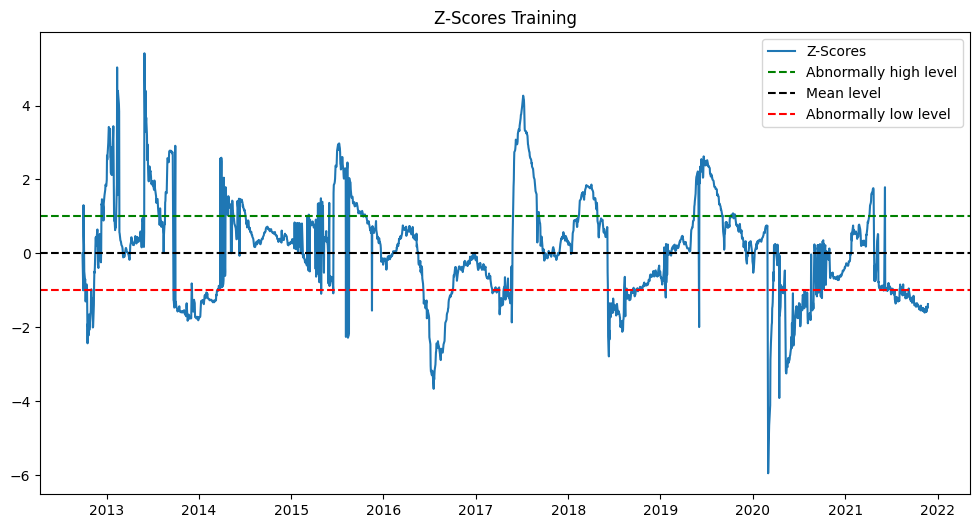

In [29]:
LOOKBACK = 252
hedge_train = np.full((len(df_train), 3), np.nan)
rolling_spread = np.full(len(df_train), np.nan)

for i in range(LOOKBACK, len(df_train)):
    window = df_train.iloc[i-LOOKBACK:i]
    result_window = coint_johansen(window, det_order=0, k_ar_diff=1)
    hedge_train[i] = result_window.evec[:, 0]
    rolling_spread[i] = (df_train.iloc[i].values * result_window.evec[:, 0]).sum()

rolling_spread_series = pd.Series(rolling_spread, index=df_train.index)

z_scores = np.full(len(rolling_spread_series), np.nan)
for i in range(LOOKBACK, len(rolling_spread_series)):
    window_rolling_spread = rolling_spread_series.iloc[i-LOOKBACK:i]
    mean_rolling_spread = np.mean(window_rolling_spread)
    std_rolling_spread = np.std(window_rolling_spread)
    if std_rolling_spread == 0:
        z_scores[i] = 0
    else:
        z_scores[i] = (window_rolling_spread.iloc[-1] - mean_rolling_spread) / std_rolling_spread

thresholds = [1.0, 1.5, 2.0, 2.5, 3.0]
results = {}

for entry in thresholds:
    positions = np.zeros(len(z_scores))
    position = 0
    for j in range(len(z_scores)):
        if np.isnan(z_scores[j]):
            position = 0
        elif z_scores[j] >= entry:
            position = -1
        elif z_scores[j] <= -entry:
            position = 1
        elif position == 1 and z_scores[j] >= 0:
            position = 0
        elif position == -1 and z_scores[j] <= 0:
            position = 0
        positions[j] = position
    
    spread_changes = rolling_spread_series.diff()
    pnl = positions * spread_changes
    sharpe_ratio = np.mean(pnl) / np.std(pnl) * np.sqrt(252)
    results[entry] = sharpe_ratio

best_threshold = max(results, key=results.get)
print(results)
print(f'Best threshold: {best_threshold}')

plt.figure(figsize=(12,6))
plt.plot(df_train.index, z_scores, label='Z-Scores')
plt.axhline(y=best_threshold, color='green', linestyle='--', label='Abnormally high level')
plt.axhline(y=0, color='black', linestyle='--', label='Mean level')
plt.axhline(y=-best_threshold, color='red', linestyle='--', label='Abnormally low level')
plt.title('Z-Scores Training')
plt.legend()
plt.show()

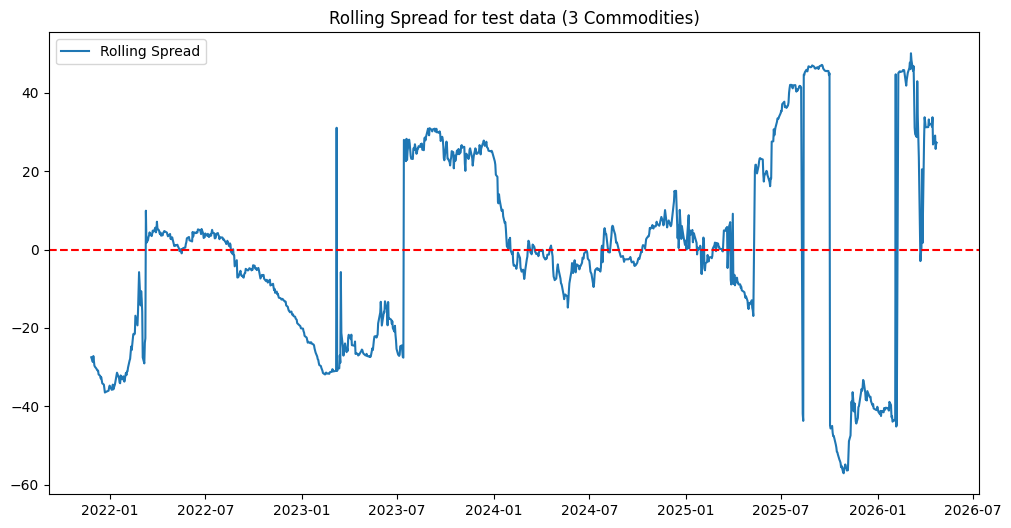

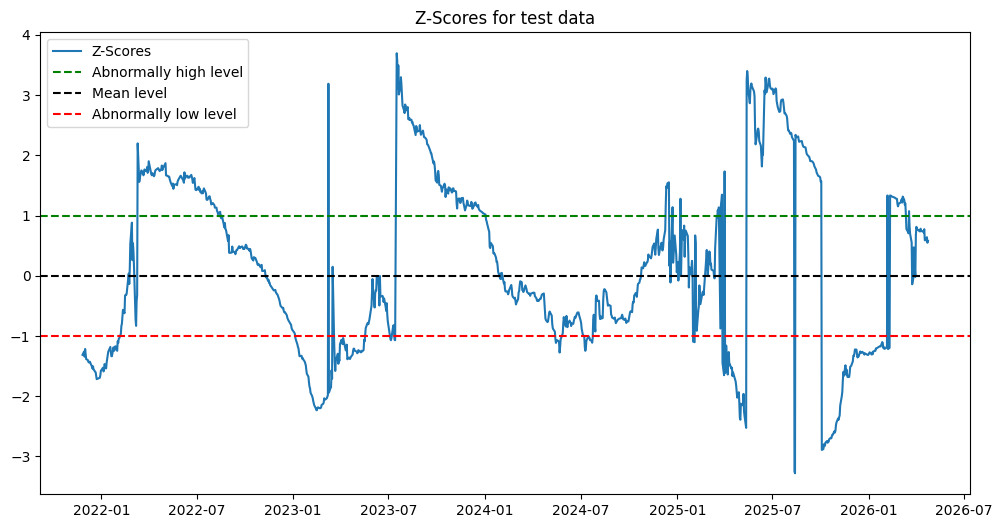

In [30]:
hedge_final = np.full((len(df), 3), np.nan)
spread_final = np.full(len(df), np.nan)

for i in range(LOOKBACK, len(df)):
    window = df.iloc[i-LOOKBACK:i]
    result_window = coint_johansen(window, det_order=0, k_ar_diff=1)
    hedge_final[i] = result_window.evec[:, 0]
    spread_final[i] = (df.iloc[i].values * result_window.evec[:, 0]).sum()

spread_final_series = pd.Series(spread_final, index=df.index)
hedge_final_df = pd.DataFrame(hedge_final, index=df.index, columns=['Corn', 'Soybean', 'Wheat'])

z_scores_final = np.full(len(spread_final_series), np.nan)
for j in range(LOOKBACK, len(df)):
    window_spread_final = spread_final_series.iloc[j-LOOKBACK:j]
    mean_spread_final = np.mean(window_spread_final)
    std_spread_final = np.std(window_spread_final)
    if std_spread_final == 0:
        z_scores_final[j] = 0
    else:
        z_scores_final[j] = (window_spread_final.iloc[-1] - mean_spread_final) / std_spread_final

z_scores_final_series = pd.Series(z_scores_final, index=df.index)

z_scores_test = z_scores_final_series[df.index >= df_test.index[0]]
spread_test = spread_final_series[df.index >= df_test.index[0]]

plt.figure(figsize=(12,6))
plt.plot(df_test.index, spread_test, label='Rolling Spread')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Rolling Spread for test data (3 Commodities)')
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df_test.index, z_scores_test, label='Z-Scores')
plt.axhline(y=best_threshold, color='green', linestyle='--', label='Abnormally high level')
plt.axhline(y=0, color='black', linestyle='--', label='Mean level')
plt.axhline(y=-best_threshold, color='red', linestyle='--', label='Abnormally low level')
plt.title('Z-Scores for test data')
plt.legend()
plt.show()

Sharpe Ratio:   -0.088
Total Return:   -4.06%
Max Drawdown:   -16.57%
Total P&L:      -3.79


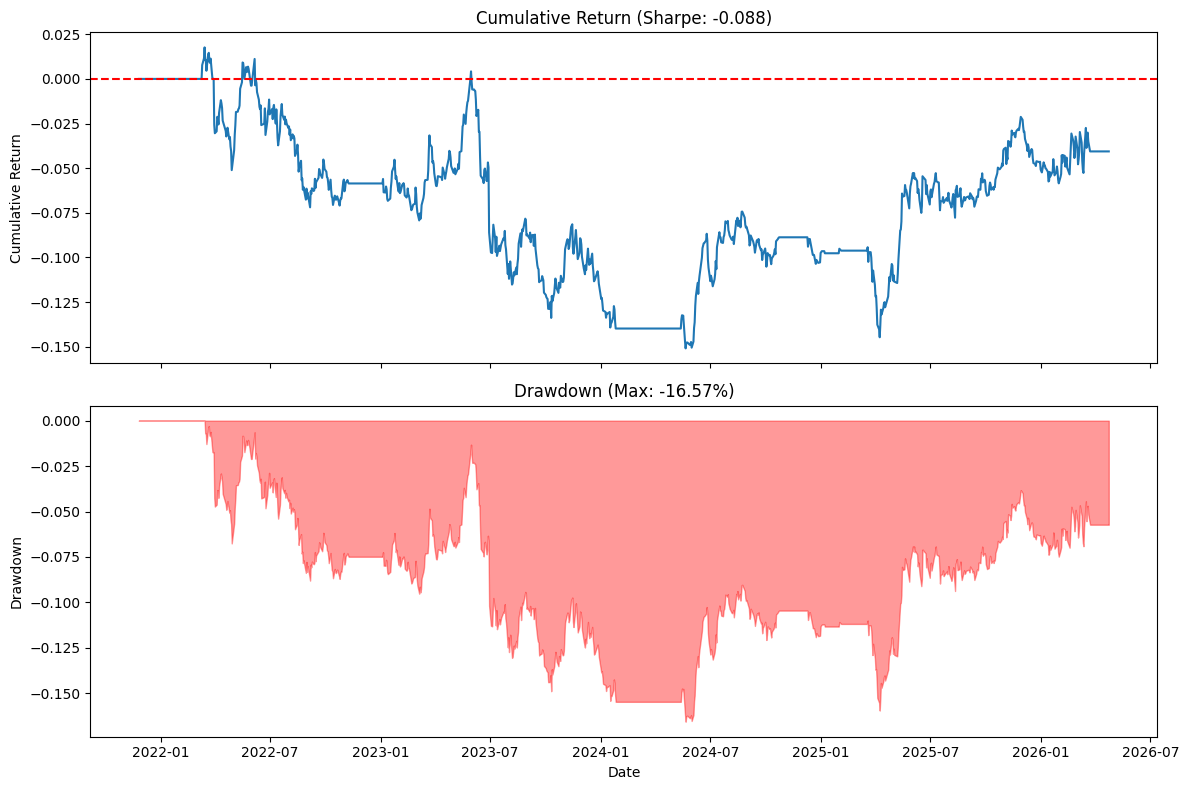

In [31]:
THRESHOLD = best_threshold

positions_final = np.zeros(len(z_scores_test))
position_final = 0
for i in range(len(z_scores_test)):
    if np.isnan(z_scores_test.iloc[i]):
        position_final = 0
    elif z_scores_test.iloc[i] >= THRESHOLD:
        position_final = -1
    elif z_scores_test.iloc[i] <= -THRESHOLD:
        position_final = 1
    elif position_final == 1 and z_scores_test.iloc[i] >= 0:
        position_final = 0
    elif position_final == -1 and z_scores_test.iloc[i] <= 0:
        position_final = 0
    positions_final[i] = position_final

split = int(len(df) * 0.7)
hedge_test = hedge_final[split:]
corn_test = df_test['Corn'].values
soy_test = df_test['Soybean'].values
wheat_test = df_test['Wheat'].values
delta_corn = df_test['Corn'].diff().values
delta_soy = df_test['Soybean'].diff().values
delta_wheat = df_test['Wheat'].diff().values

pnl_fixed = np.zeros(len(positions_final))
returns = np.zeros(len(positions_final))
hedge_entry = None
capital_entry = np.nan

for i in range(1, len(positions_final)):
    prev_pos = positions_final[i-1]
    curr_pos = positions_final[i]
    
    if prev_pos == 0 and curr_pos != 0:
        hedge_entry = hedge_test[i]
        capital_entry = (abs(hedge_entry[0]) * corn_test[i-1] + 
                        abs(hedge_entry[1]) * soy_test[i-1] + 
                        abs(hedge_entry[2]) * wheat_test[i-1])
    
    if curr_pos != 0 and hedge_entry is not None:
        pnl_fixed[i] = curr_pos * (hedge_entry[0] * delta_corn[i] + 
                                    hedge_entry[1] * delta_soy[i] + 
                                    hedge_entry[2] * delta_wheat[i])
        returns[i] = pnl_fixed[i] / capital_entry
    else:
        pnl_fixed[i] = 0.0
        returns[i] = 0.0
    
    if curr_pos == 0:
        hedge_entry = None
        capital_entry = np.nan

returns = pd.Series(returns, index=df_test.index)
pnl_fixed = pd.Series(pnl_fixed, index=df_test.index)

sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252) if np.std(returns) > 0 else 0
cum_ret = (1 + returns).cumprod() - 1
total_ret = cum_ret.iloc[-1]
rolling_max = (1 + returns).cumprod().cummax()
drawdown = (1 + returns).cumprod() / rolling_max - 1
max_dd = drawdown.min()

print(f'Sharpe Ratio:   {sharpe:.3f}')
print(f'Total Return:   {total_ret:.2%}')
print(f'Max Drawdown:   {max_dd:.2%}')
print(f'Total P&L:      {pnl_fixed.sum():.2f}')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(cum_ret.index, cum_ret.values)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'Cumulative Return (Sharpe: {sharpe:.3f})')
axes[0].set_ylabel('Cumulative Return')

axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.4, color='red')
axes[1].set_title(f'Drawdown (Max: {max_dd:.2%})')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

### Combination 2: Corn + Soybean + Cotton

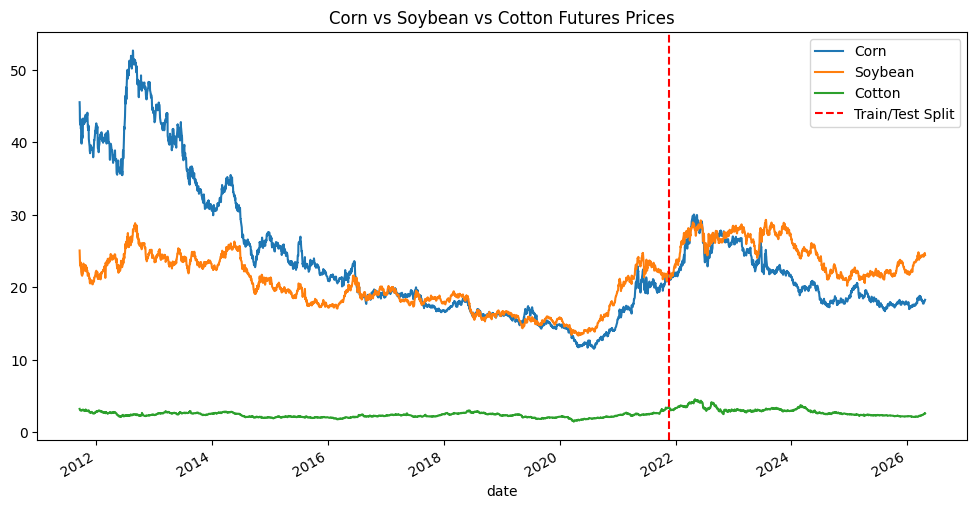

In [32]:
df1=pd.read_csv(r'C:\Users\zezar\TilburgUniversity\Spring2026-TIC\Ensemble_Wiktor\data\merged_corn_soybean_wheat_cotton.csv', skiprows=[1], index_col=0, parse_dates=True)
corn=df1['close_corn']
soybean=df1['close_soybean']
cotton=df1['close_cotton']


df=pd.concat([corn, soybean, cotton], axis=1)
df.columns=['Corn', 'Soybean', 'Cotton']

df_train=df.iloc[:int(len(df)*0.7)]
df_test=df.iloc[int(len(df)*0.7):]

plt.figure(figsize=(12, 6))

df['Corn'].plot(label='Corn')
df['Soybean'].plot(label='Soybean')
df['Cotton'].plot(label='Cotton')

plt.axvline(x=df_train.index[-1], color='red', linestyle='--', label='Train/Test Split')
plt.title('Corn vs Soybean vs Cotton Futures Prices')
plt.legend()
plt.show()


In [33]:
adf_corn=adfuller(df_train['Corn'])
adf_soybean=adfuller(df_train['Soybean'])
adf_cotton=adfuller(df_train['Cotton'])

print(f'ADF Statistic for Corn: {adf_corn[0]}')
print(f'p-value for Corn: {adf_corn[1]}')
print(f'ADF Statistic for Soybean: {adf_soybean[0]}')
print(f'p-value for Soybean: {adf_soybean[1]}')
print(f'ADF Statistic for Cotton: {adf_cotton[0]}')
print(f'p-value for Cotton: {adf_cotton[1]}')
print(f'Critical Values: {adf_corn[4]}')


ADF Statistic for Corn: -1.9416474883191506
p-value for Corn: 0.31272943996111335
ADF Statistic for Soybean: -1.8500507300892937
p-value for Soybean: 0.3559109696697546
ADF Statistic for Cotton: -2.301365976236572
p-value for Cotton: 0.17152779547395824
Critical Values: {'1%': -3.4329747166494915, '5%': -2.862699584647827, '10%': -2.567387292022104}


In [34]:
corn_diff=df_train['Corn'].diff().dropna()
adf_corn_diff=adfuller(corn_diff)

soybean_diff=df_train['Soybean'].diff().dropna()
adf_soybean_diff=adfuller(soybean_diff)

cotton_diff=df_train['Cotton'].diff().dropna()
adf_cotton_diff=adfuller(cotton_diff)

print(f'ADF Statistic for Corn: {adf_corn_diff[0]}')
print(f'p-value for Corn: {adf_corn_diff[1]}')
print(f'ADF Statistic for Soybean: {adf_soybean_diff[0]}')
print(f'p-value for Soybean: {adf_soybean_diff[1]}')
print(f'ADF Statistic for Cotton: {adf_cotton_diff[0]}')
print(f'p-value for Cotton: {adf_cotton_diff[1]}')
print(f'Critical Values: {adf_corn_diff[4]}')


ADF Statistic for Corn: -9.171156001601226
p-value for Corn: 2.38636435725362e-15
ADF Statistic for Soybean: -56.092950108524676
p-value for Soybean: 0.0
ADF Statistic for Cotton: -51.93705238817174
p-value for Cotton: 0.0
Critical Values: {'1%': -3.4329747166494915, '5%': -2.862699584647827, '10%': -2.567387292022104}


In [35]:
result = coint_johansen(df_train, det_order=0, k_ar_diff=1)

print('Trace Statistics:')
print(result.lr1)
print('Critical values 90%, 95%, 99%:')
print(result.cvt)

print('\nEigen Statistics:')
print(result.lr2)
print('Critical values 90%, 95%, 99%:')
print(result.cvm)

print('\nEigenvalues:')
print(result.eig)

print('\nEigenvectors:')
print(result.evec)


Trace Statistics:
[20.4961245   6.93097293  2.25505371]
Critical values 90%, 95%, 99%:
[[27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]

Eigen Statistics:
[13.56515157  4.67591922  2.25505371]
Critical values 90%, 95%, 99%:
[[18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]

Eigenvalues:
[0.00536853 0.0018538  0.00089446]

Eigenvectors:
[[ 0.13608629  0.03469457 -0.11778377]
 [-0.50699848 -0.2954763   0.06500857]
 [ 2.61666844 -1.26637587  2.45090616]]


In [36]:
hedge_ratios = result.evec[:, 0]
print(f'Corn:    {hedge_ratios[0]:.4f}')
print(f'Soybean: {hedge_ratios[1]:.4f}')
print(f'Cotton:   {hedge_ratios[2]:.4f}')


Corn:    0.1361
Soybean: -0.5070
Cotton:   2.6167


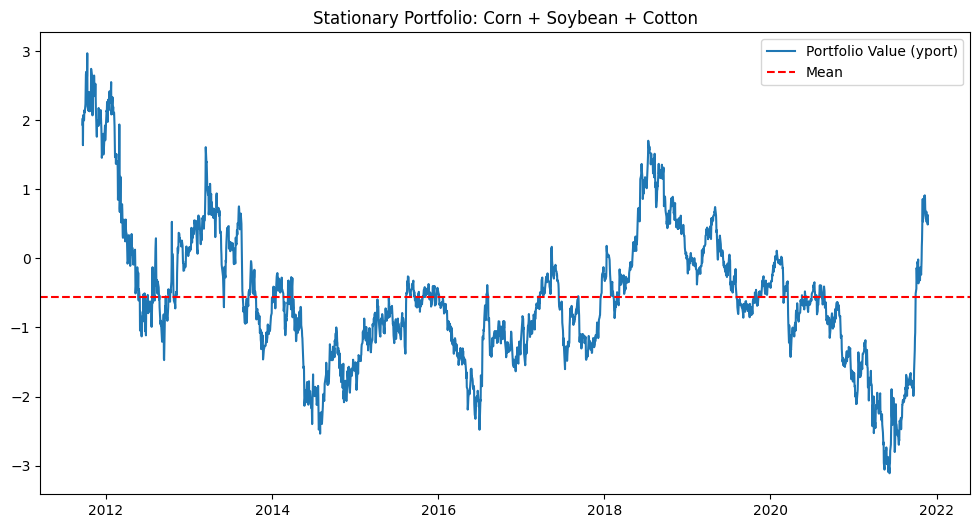


ADF Statistic: -3.3838
p-value: 0.0115
Critical Values: {'1%': -3.4329476085791493, '5%': -2.8626876136761292, '10%': -2.5673809185248175}


In [37]:
yport = (df_train * hedge_ratios).sum(axis=1)

plt.figure(figsize=(12, 6))
plt.plot(yport.index, yport.values, label='Portfolio Value (yport)')
plt.axhline(yport.mean(), color='red', linestyle='--', label='Mean')
plt.title('Stationary Portfolio: Corn + Soybean + Cotton')
plt.legend()
plt.show()

adf_yport = adfuller(yport, maxlag=1, autolag=None)
print(f'\nADF Statistic: {adf_yport[0]:.4f}')
print(f'p-value: {adf_yport[1]:.4f}')
print(f'Critical Values: {adf_yport[4]}')


In [38]:
yport_diff = yport.diff().dropna()
yport_lagged = yport.shift(1).dropna()
yport_lagged = sm.add_constant(yport_lagged)
model_hl = sm.OLS(yport_diff, yport_lagged)
result_hl = model_hl.fit()
lambda_val = result_hl.params.iloc[1]
half_life = -np.log(2) / lambda_val
print(f'Half life: {half_life:.1f} days')


Half life: 72.8 days


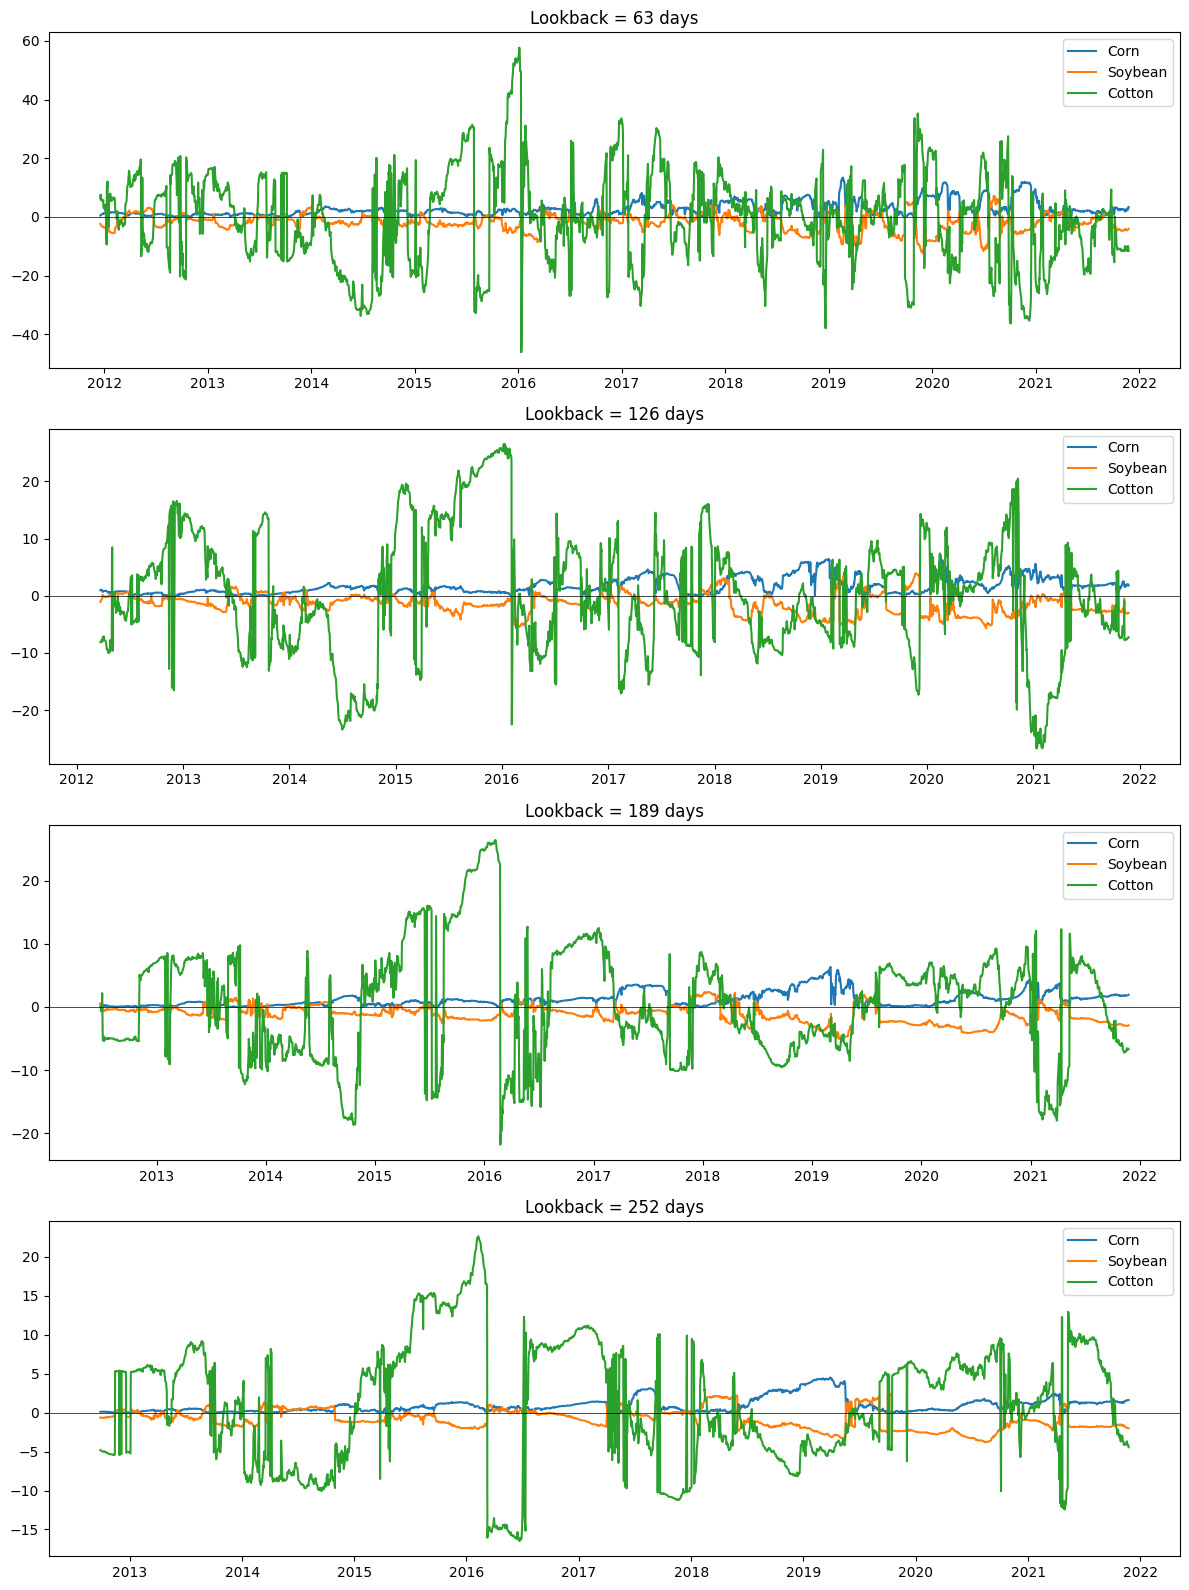

In [39]:
def rolling_eigenvectors(df_train, lookback):
    n_assets = df_train.shape[1]
    eigenvectors = np.full((len(df_train), n_assets), np.nan)
    
    for i in range(lookback, len(df_train)):
        window = df_train.iloc[i-lookback:i]
        try:
            result = coint_johansen(window, det_order=0, k_ar_diff=1)
            eigenvectors[i] = result.evec[:, 0]
        except:
            pass
    
    return pd.DataFrame(eigenvectors, index=df_train.index, columns=df_train.columns)

fig, axes = plt.subplots(4, 1, figsize=(12, 16))
for ax, lb in zip(axes, [63, 126, 189, 252]):
    eigvec = rolling_eigenvectors(df_train, lb)
    for col in eigvec.columns:
        ax.plot(eigvec.index, eigvec[col], label=col)
    ax.set_title(f'Lookback = {lb} days')
    ax.legend()
    ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


{1.0: 2.109863217284534, 1.5: 1.7255912661152646, 2.0: 1.259669935359056, 2.5: 1.0337846965832707, 3.0: 0.22919054637361505}
Best threshold: 1.0


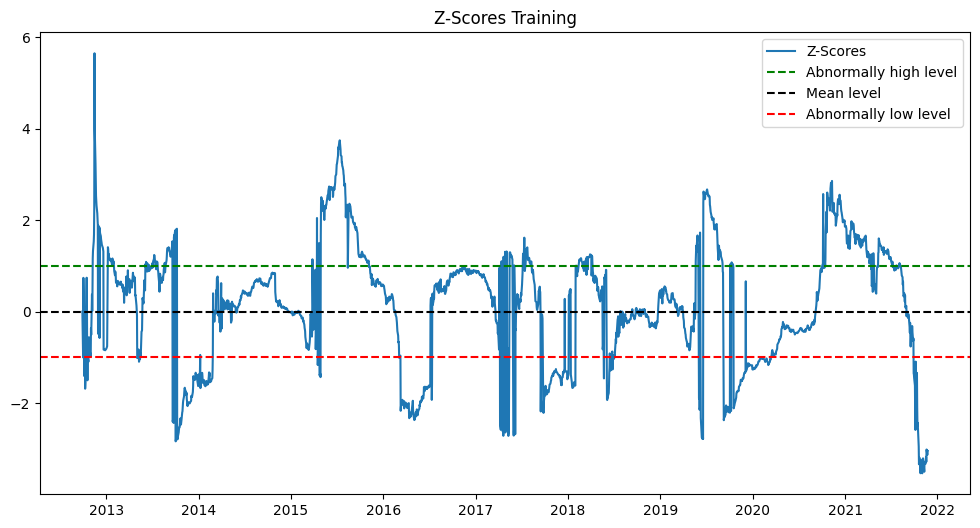

In [40]:
LOOKBACK = 252
hedge_train = np.full((len(df_train), 3), np.nan)
rolling_spread = np.full(len(df_train), np.nan)

for i in range(LOOKBACK, len(df_train)):
    window = df_train.iloc[i-LOOKBACK:i]
    result_window = coint_johansen(window, det_order=0, k_ar_diff=1)
    hedge_train[i] = result_window.evec[:, 0]
    rolling_spread[i] = (df_train.iloc[i].values * result_window.evec[:, 0]).sum()

rolling_spread_series = pd.Series(rolling_spread, index=df_train.index)

z_scores = np.full(len(rolling_spread_series), np.nan)
for i in range(LOOKBACK, len(rolling_spread_series)):
    window_rolling_spread = rolling_spread_series.iloc[i-LOOKBACK:i]
    mean_rolling_spread = np.mean(window_rolling_spread)
    std_rolling_spread = np.std(window_rolling_spread)
    if std_rolling_spread == 0:
        z_scores[i] = 0
    else:
        z_scores[i] = (window_rolling_spread.iloc[-1] - mean_rolling_spread) / std_rolling_spread

thresholds = [1.0, 1.5, 2.0, 2.5, 3.0]
results_opt = {}

for entry in thresholds:
    positions = np.zeros(len(z_scores))
    position = 0
    for j in range(len(z_scores)):
        if np.isnan(z_scores[j]):
            position = 0
        elif z_scores[j] >= entry:
            position = -1
        elif z_scores[j] <= -entry:
            position = 1
        elif position == 1 and z_scores[j] >= 0:
            position = 0
        elif position == -1 and z_scores[j] <= 0:
            position = 0
        positions[j] = position
    
    spread_changes = rolling_spread_series.diff()
    pnl = positions * spread_changes
    if np.std(pnl) > 0:
        sharpe_ratio = np.mean(pnl) / np.std(pnl) * np.sqrt(252)
    else:
        sharpe_ratio = 0
    results_opt[entry] = sharpe_ratio

best_threshold = max(results_opt, key=results_opt.get)
print(results_opt)
print(f'Best threshold: {best_threshold}')

plt.figure(figsize=(12,6))
plt.plot(df_train.index, z_scores, label='Z-Scores')
plt.axhline(y=best_threshold, color='green', linestyle='--', label='Abnormally high level')
plt.axhline(y=0, color='black', linestyle='--', label='Mean level')
plt.axhline(y=-best_threshold, color='red', linestyle='--', label='Abnormally low level')
plt.title('Z-Scores Training')
plt.legend()
plt.show()


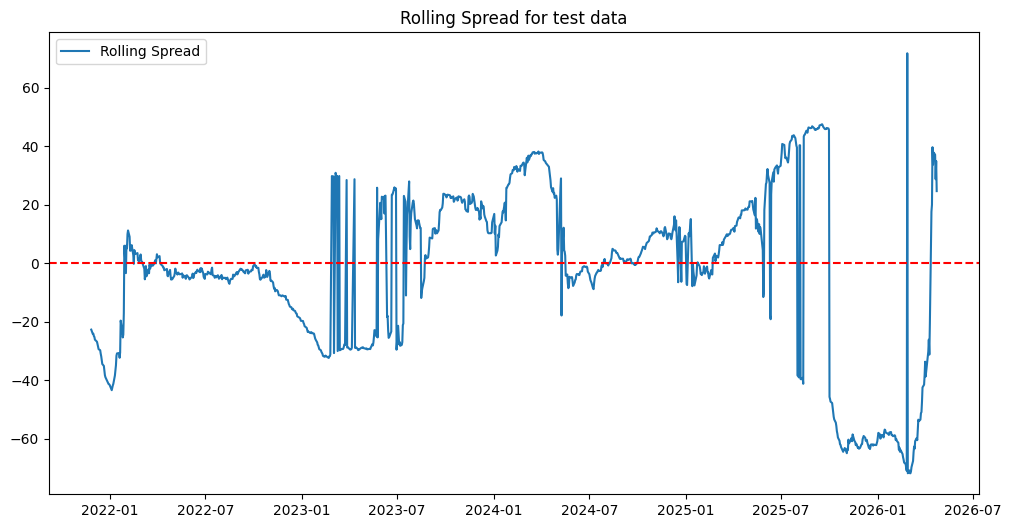

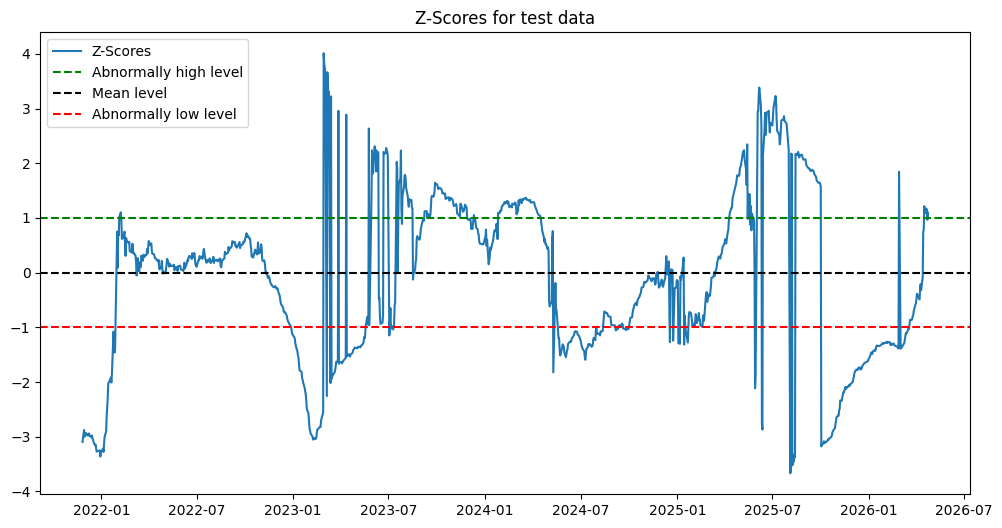

In [41]:
hedge_final = np.full((len(df), 3), np.nan)
spread_final = np.full(len(df), np.nan)

for i in range(LOOKBACK, len(df)):
    window = df.iloc[i-LOOKBACK:i]
    result_window = coint_johansen(window, det_order=0, k_ar_diff=1)
    hedge_final[i] = result_window.evec[:, 0]
    spread_final[i] = (df.iloc[i].values * result_window.evec[:, 0]).sum()

spread_final_series = pd.Series(spread_final, index=df.index)
hedge_final_df = pd.DataFrame(hedge_final, index=df.index, columns=['Corn', 'Soybean', 'Cotton'])

z_scores_final = np.full(len(spread_final_series), np.nan)
for j in range(LOOKBACK, len(df)):
    window_spread_final = spread_final_series.iloc[j-LOOKBACK:j]
    mean_spread_final = np.mean(window_spread_final)
    std_spread_final = np.std(window_spread_final)
    if std_spread_final == 0:
        z_scores_final[j] = 0
    else:
        z_scores_final[j] = (window_spread_final.iloc[-1] - mean_spread_final) / std_spread_final

z_scores_final_series = pd.Series(z_scores_final, index=df.index)
z_scores_test = z_scores_final_series[df.index >= df_test.index[0]]
spread_test = spread_final_series[df.index >= df_test.index[0]]

plt.figure(figsize=(12,6))
plt.plot(df_test.index, spread_test, label='Rolling Spread')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Rolling Spread for test data')
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df_test.index, z_scores_test, label='Z-Scores')
plt.axhline(y=best_threshold, color='green', linestyle='--', label='Abnormally high level')
plt.axhline(y=0, color='black', linestyle='--', label='Mean level')
plt.axhline(y=-best_threshold, color='red', linestyle='--', label='Abnormally low level')
plt.title('Z-Scores for test data')
plt.legend()
plt.show()


Sharpe Ratio:   0.243
Total Return:   8.15%
Max Drawdown:   -16.19%
Total P&L:      4.34


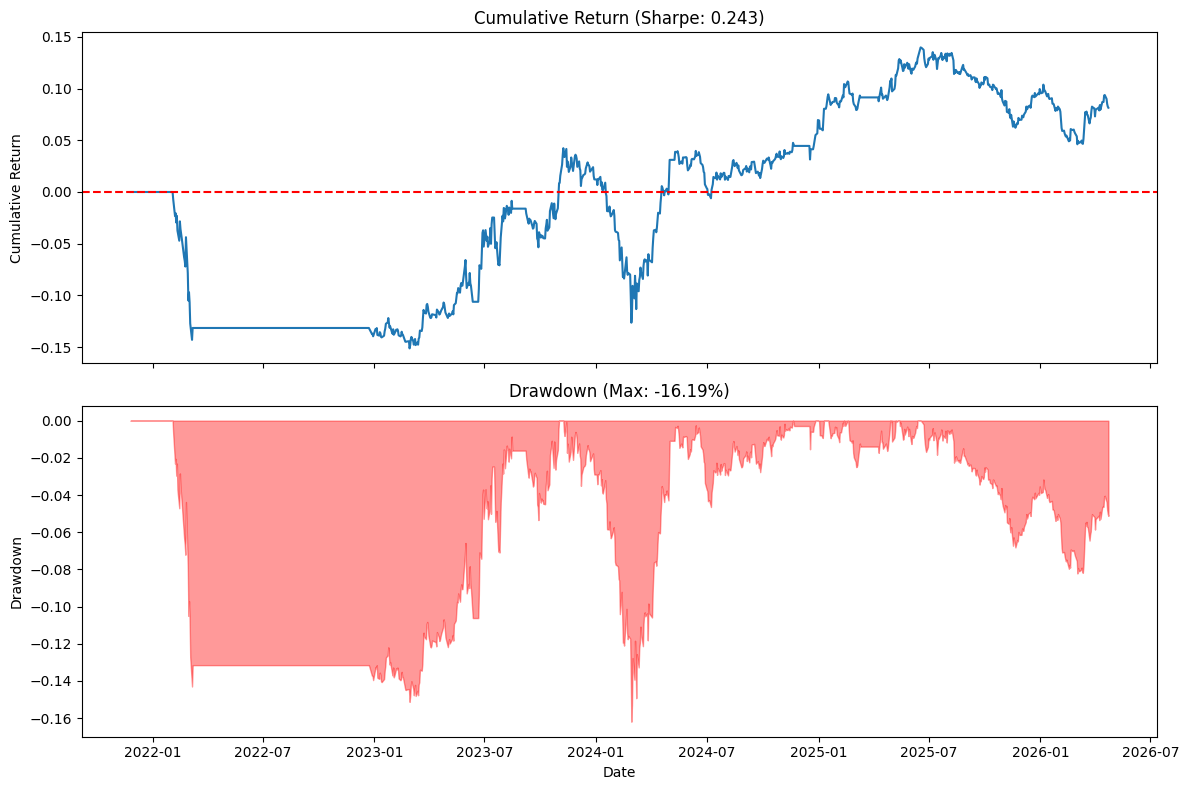

In [42]:
THRESHOLD = best_threshold

positions_final = np.zeros(len(z_scores_test))
position_final = 0
for i in range(len(z_scores_test)):
    if np.isnan(z_scores_test.iloc[i]):
        position_final = 0
    elif z_scores_test.iloc[i] >= THRESHOLD:
        position_final = -1
    elif z_scores_test.iloc[i] <= -THRESHOLD:
        position_final = 1
    elif position_final == 1 and z_scores_test.iloc[i] >= 0:
        position_final = 0
    elif position_final == -1 and z_scores_test.iloc[i] <= 0:
        position_final = 0
    positions_final[i] = position_final

split = int(len(df) * 0.7)
hedge_test = hedge_final[split:]
corn_test = df_test['Corn'].values
soybean_test = df_test['Soybean'].values
cotton_test = df_test['Cotton'].values
delta_corn = df_test['Corn'].diff().values
delta_soybean = df_test['Soybean'].diff().values
delta_cotton = df_test['Cotton'].diff().values

pnl_fixed = np.zeros(len(positions_final))
returns = np.zeros(len(positions_final))
hedge_entry = None
capital_entry = np.nan

for i in range(1, len(positions_final)):
    prev_pos = positions_final[i-1]
    curr_pos = positions_final[i]
    
    if prev_pos == 0 and curr_pos != 0:
        hedge_entry = hedge_test[i]
        capital_entry = (abs(hedge_entry[0]) * corn_test[i-1] +
                         abs(hedge_entry[1]) * soybean_test[i-1] +
                         abs(hedge_entry[2]) * cotton_test[i-1])
    
    if curr_pos != 0 and hedge_entry is not None:
        pnl_fixed[i] = curr_pos * (hedge_entry[0] * delta_corn[i] +
                                    hedge_entry[1] * delta_soybean[i] +
                                    hedge_entry[2] * delta_cotton[i])
        returns[i] = pnl_fixed[i] / capital_entry
    else:
        pnl_fixed[i] = 0.0
        returns[i] = 0.0
    
    if curr_pos == 0:
        hedge_entry = None
        capital_entry = np.nan

returns = pd.Series(returns, index=df_test.index)
pnl_fixed = pd.Series(pnl_fixed, index=df_test.index)

sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252) if np.std(returns) > 0 else 0
cum_ret = (1 + returns).cumprod() - 1
total_ret = cum_ret.iloc[-1]
rolling_max = (1 + returns).cumprod().cummax()
drawdown = (1 + returns).cumprod() / rolling_max - 1
max_dd = drawdown.min()

print(f'Sharpe Ratio:   {sharpe:.3f}')
print(f'Total Return:   {total_ret:.2%}')
print(f'Max Drawdown:   {max_dd:.2%}')
print(f'Total P&L:      {pnl_fixed.sum():.2f}')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(cum_ret.index, cum_ret.values)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'Cumulative Return (Sharpe: {sharpe:.3f})')
axes[0].set_ylabel('Cumulative Return')

axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.4, color='red')
axes[1].set_title(f'Drawdown (Max: {max_dd:.2%})')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()


### Combination 3: Corn + Wheat + Cotton

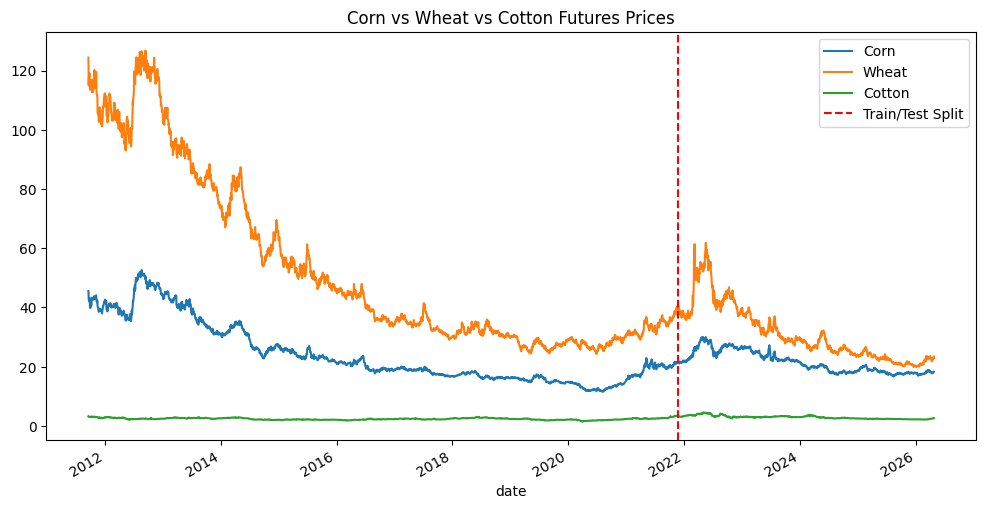

In [43]:
df1=pd.read_csv(r'C:\Users\zezar\TilburgUniversity\Spring2026-TIC\Ensemble_Wiktor\data\merged_corn_soybean_wheat_cotton.csv', skiprows=[1], index_col=0, parse_dates=True)
corn=df1['close_corn']
wheat=df1['close_wheat']
cotton=df1['close_cotton']


df=pd.concat([corn, wheat, cotton], axis=1)
df.columns=['Corn', 'Wheat', 'Cotton']

df_train=df.iloc[:int(len(df)*0.7)]
df_test=df.iloc[int(len(df)*0.7):]

plt.figure(figsize=(12, 6))

df['Corn'].plot(label='Corn')
df['Wheat'].plot(label='Wheat')
df['Cotton'].plot(label='Cotton')

plt.axvline(x=df_train.index[-1], color='red', linestyle='--', label='Train/Test Split')
plt.title('Corn vs Wheat vs Cotton Futures Prices')
plt.legend()
plt.show()


In [44]:
adf_corn=adfuller(df_train['Corn'])
adf_wheat=adfuller(df_train['Wheat'])
adf_cotton=adfuller(df_train['Cotton'])

print(f'ADF Statistic for Corn: {adf_corn[0]}')
print(f'p-value for Corn: {adf_corn[1]}')
print(f'ADF Statistic for Wheat: {adf_wheat[0]}')
print(f'p-value for Wheat: {adf_wheat[1]}')
print(f'ADF Statistic for Cotton: {adf_cotton[0]}')
print(f'p-value for Cotton: {adf_cotton[1]}')
print(f'Critical Values: {adf_corn[4]}')


ADF Statistic for Corn: -1.9416474883191506
p-value for Corn: 0.31272943996111335
ADF Statistic for Wheat: -2.2212542264301733
p-value for Wheat: 0.19862202636181386
ADF Statistic for Cotton: -2.301365976236572
p-value for Cotton: 0.17152779547395824
Critical Values: {'1%': -3.4329747166494915, '5%': -2.862699584647827, '10%': -2.567387292022104}


In [45]:
corn_diff=df_train['Corn'].diff().dropna()
adf_corn_diff=adfuller(corn_diff)

wheat_diff=df_train['Wheat'].diff().dropna()
adf_wheat_diff=adfuller(wheat_diff)

cotton_diff=df_train['Cotton'].diff().dropna()
adf_cotton_diff=adfuller(cotton_diff)

print(f'ADF Statistic for Corn: {adf_corn_diff[0]}')
print(f'p-value for Corn: {adf_corn_diff[1]}')
print(f'ADF Statistic for Wheat: {adf_wheat_diff[0]}')
print(f'p-value for Wheat: {adf_wheat_diff[1]}')
print(f'ADF Statistic for Cotton: {adf_cotton_diff[0]}')
print(f'p-value for Cotton: {adf_cotton_diff[1]}')
print(f'Critical Values: {adf_corn_diff[4]}')


ADF Statistic for Corn: -9.171156001601226
p-value for Corn: 2.38636435725362e-15
ADF Statistic for Wheat: -11.396413869426183
p-value for Wheat: 7.838538580427442e-21
ADF Statistic for Cotton: -51.93705238817174
p-value for Cotton: 0.0
Critical Values: {'1%': -3.4329747166494915, '5%': -2.862699584647827, '10%': -2.567387292022104}


In [46]:
result = coint_johansen(df_train, det_order=0, k_ar_diff=1)

print('Trace Statistics:')
print(result.lr1)
print('Critical values 90%, 95%, 99%:')
print(result.cvt)

print('\nEigen Statistics:')
print(result.lr2)
print('Critical values 90%, 95%, 99%:')
print(result.cvm)

print('\nEigenvalues:')
print(result.eig)

print('\nEigenvectors:')
print(result.evec)


Trace Statistics:
[35.61366869  9.73555014  2.72084372]
Critical values 90%, 95%, 99%:
[[27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]

Eigen Statistics:
[25.87811856  7.01470642  2.72084372]
Critical values 90%, 95%, 99%:
[[18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]

Eigenvalues:
[0.01021655 0.00277974 0.00107912]

Eigenvectors:
[[ 0.60473661 -0.14947659  0.05376277]
 [-0.21164489  0.0335545   0.014505  ]
 [-1.18766858 -1.84484531 -2.88245717]]


In [47]:
hedge_ratios = result.evec[:, 0]
print(f'Corn:    {hedge_ratios[0]:.4f}')
print(f'Wheat: {hedge_ratios[1]:.4f}')
print(f'Cotton:   {hedge_ratios[2]:.4f}')


Corn:    0.6047
Wheat: -0.2116
Cotton:   -1.1877


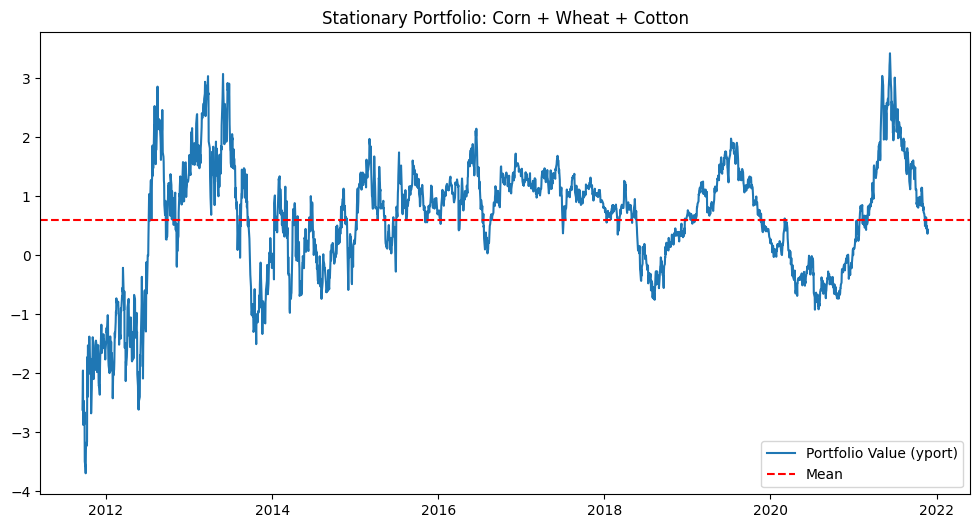


ADF Statistic: -4.7578
p-value: 0.0001
Critical Values: {'1%': -3.4329476085791493, '5%': -2.8626876136761292, '10%': -2.5673809185248175}


In [48]:
yport = (df_train * hedge_ratios).sum(axis=1)

plt.figure(figsize=(12, 6))
plt.plot(yport.index, yport.values, label='Portfolio Value (yport)')
plt.axhline(yport.mean(), color='red', linestyle='--', label='Mean')
plt.title('Stationary Portfolio: Corn + Wheat + Cotton')
plt.legend()
plt.show()

adf_yport = adfuller(yport, maxlag=1, autolag=None)
print(f'\nADF Statistic: {adf_yport[0]:.4f}')
print(f'p-value: {adf_yport[1]:.4f}')
print(f'Critical Values: {adf_yport[4]}')


In [49]:
yport_diff = yport.diff().dropna()
yport_lagged = yport.shift(1).dropna()
yport_lagged = sm.add_constant(yport_lagged)
model_hl = sm.OLS(yport_diff, yport_lagged)
result_hl = model_hl.fit()
lambda_val = result_hl.params.iloc[1]
half_life = -np.log(2) / lambda_val
print(f'Half life: {half_life:.1f} days')


Half life: 36.5 days


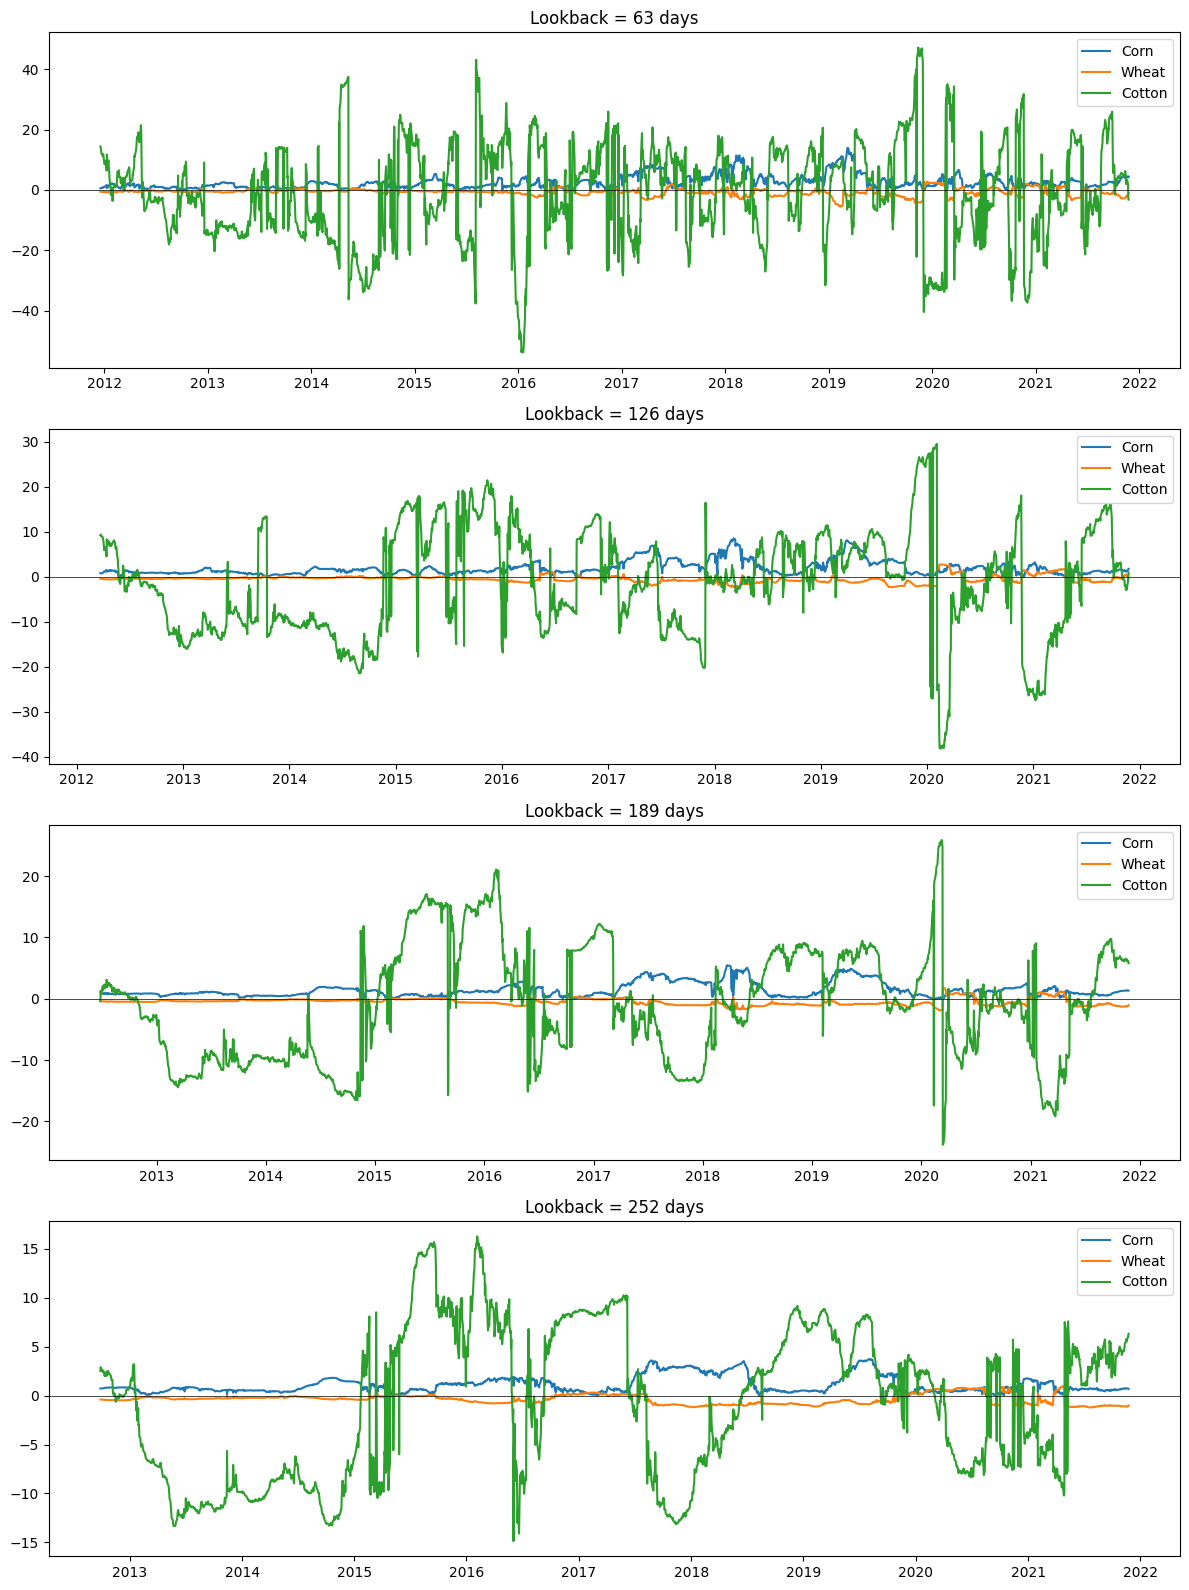

In [50]:
def rolling_eigenvectors(df_train, lookback):
    n_assets = df_train.shape[1]
    eigenvectors = np.full((len(df_train), n_assets), np.nan)
    
    for i in range(lookback, len(df_train)):
        window = df_train.iloc[i-lookback:i]
        try:
            result = coint_johansen(window, det_order=0, k_ar_diff=1)
            eigenvectors[i] = result.evec[:, 0]
        except:
            pass
    
    return pd.DataFrame(eigenvectors, index=df_train.index, columns=df_train.columns)

fig, axes = plt.subplots(4, 1, figsize=(12, 16))
for ax, lb in zip(axes, [63, 126, 189, 252]):
    eigvec = rolling_eigenvectors(df_train, lb)
    for col in eigvec.columns:
        ax.plot(eigvec.index, eigvec[col], label=col)
    ax.set_title(f'Lookback = {lb} days')
    ax.legend()
    ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


{1.0: 1.0003782196968956, 1.5: 0.7439521335737838, 2.0: 0.826241480925384, 2.5: 0.7596929971239074, 3.0: 0.5640070097467191}
Best threshold: 1.0


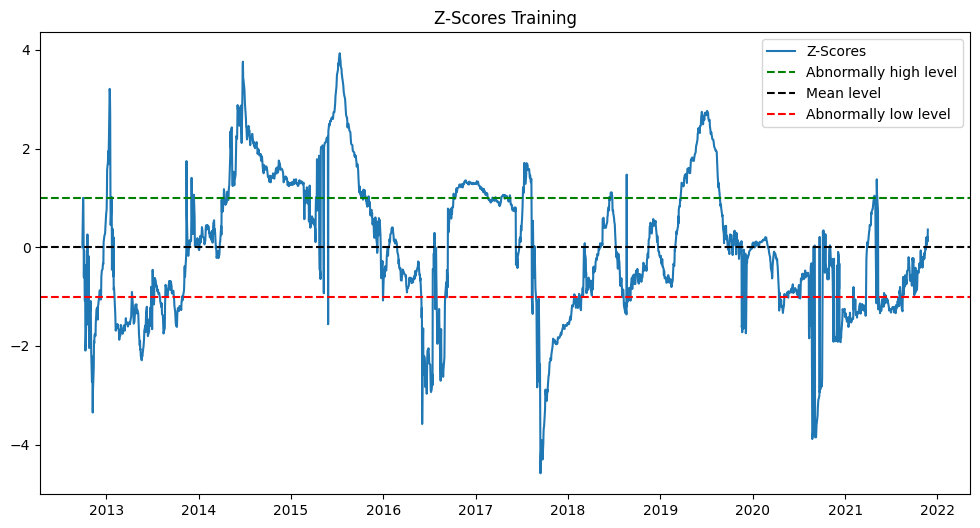

In [51]:
LOOKBACK = 252
hedge_train = np.full((len(df_train), 3), np.nan)
rolling_spread = np.full(len(df_train), np.nan)

for i in range(LOOKBACK, len(df_train)):
    window = df_train.iloc[i-LOOKBACK:i]
    result_window = coint_johansen(window, det_order=0, k_ar_diff=1)
    hedge_train[i] = result_window.evec[:, 0]
    rolling_spread[i] = (df_train.iloc[i].values * result_window.evec[:, 0]).sum()

rolling_spread_series = pd.Series(rolling_spread, index=df_train.index)

z_scores = np.full(len(rolling_spread_series), np.nan)
for i in range(LOOKBACK, len(rolling_spread_series)):
    window_rolling_spread = rolling_spread_series.iloc[i-LOOKBACK:i]
    mean_rolling_spread = np.mean(window_rolling_spread)
    std_rolling_spread = np.std(window_rolling_spread)
    if std_rolling_spread == 0:
        z_scores[i] = 0
    else:
        z_scores[i] = (window_rolling_spread.iloc[-1] - mean_rolling_spread) / std_rolling_spread

thresholds = [1.0, 1.5, 2.0, 2.5, 3.0]
results_opt = {}

for entry in thresholds:
    positions = np.zeros(len(z_scores))
    position = 0
    for j in range(len(z_scores)):
        if np.isnan(z_scores[j]):
            position = 0
        elif z_scores[j] >= entry:
            position = -1
        elif z_scores[j] <= -entry:
            position = 1
        elif position == 1 and z_scores[j] >= 0:
            position = 0
        elif position == -1 and z_scores[j] <= 0:
            position = 0
        positions[j] = position
    
    spread_changes = rolling_spread_series.diff()
    pnl = positions * spread_changes
    if np.std(pnl) > 0:
        sharpe_ratio = np.mean(pnl) / np.std(pnl) * np.sqrt(252)
    else:
        sharpe_ratio = 0
    results_opt[entry] = sharpe_ratio

best_threshold = max(results_opt, key=results_opt.get)
print(results_opt)
print(f'Best threshold: {best_threshold}')

plt.figure(figsize=(12,6))
plt.plot(df_train.index, z_scores, label='Z-Scores')
plt.axhline(y=best_threshold, color='green', linestyle='--', label='Abnormally high level')
plt.axhline(y=0, color='black', linestyle='--', label='Mean level')
plt.axhline(y=-best_threshold, color='red', linestyle='--', label='Abnormally low level')
plt.title('Z-Scores Training')
plt.legend()
plt.show()


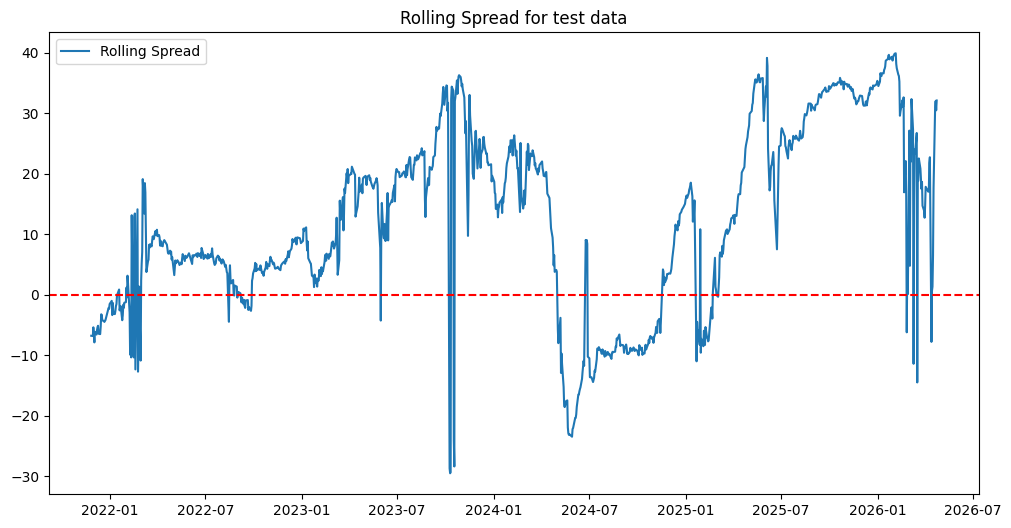

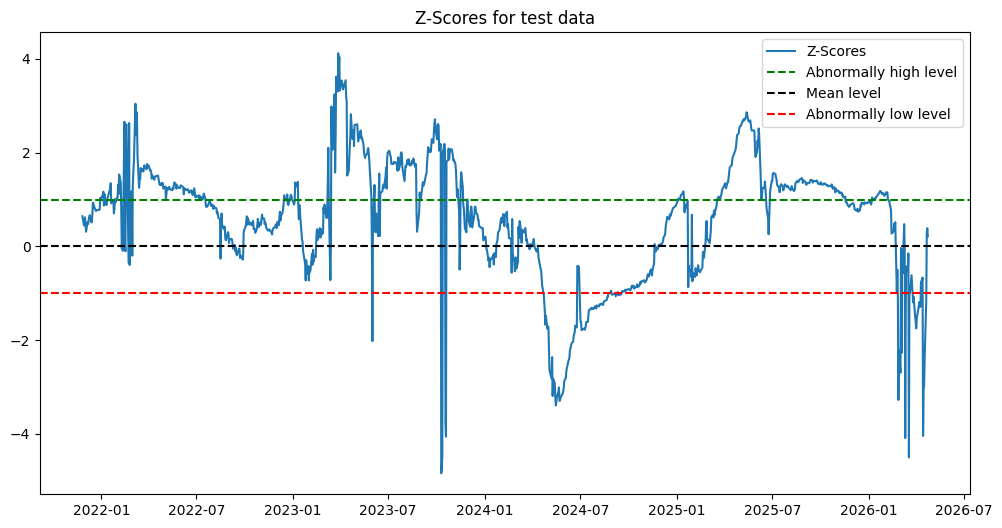

In [52]:
hedge_final = np.full((len(df), 3), np.nan)
spread_final = np.full(len(df), np.nan)

for i in range(LOOKBACK, len(df)):
    window = df.iloc[i-LOOKBACK:i]
    result_window = coint_johansen(window, det_order=0, k_ar_diff=1)
    hedge_final[i] = result_window.evec[:, 0]
    spread_final[i] = (df.iloc[i].values * result_window.evec[:, 0]).sum()

spread_final_series = pd.Series(spread_final, index=df.index)
hedge_final_df = pd.DataFrame(hedge_final, index=df.index, columns=['Corn', 'Wheat', 'Cotton'])

z_scores_final = np.full(len(spread_final_series), np.nan)
for j in range(LOOKBACK, len(df)):
    window_spread_final = spread_final_series.iloc[j-LOOKBACK:j]
    mean_spread_final = np.mean(window_spread_final)
    std_spread_final = np.std(window_spread_final)
    if std_spread_final == 0:
        z_scores_final[j] = 0
    else:
        z_scores_final[j] = (window_spread_final.iloc[-1] - mean_spread_final) / std_spread_final

z_scores_final_series = pd.Series(z_scores_final, index=df.index)
z_scores_test = z_scores_final_series[df.index >= df_test.index[0]]
spread_test = spread_final_series[df.index >= df_test.index[0]]

plt.figure(figsize=(12,6))
plt.plot(df_test.index, spread_test, label='Rolling Spread')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Rolling Spread for test data')
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df_test.index, z_scores_test, label='Z-Scores')
plt.axhline(y=best_threshold, color='green', linestyle='--', label='Abnormally high level')
plt.axhline(y=0, color='black', linestyle='--', label='Mean level')
plt.axhline(y=-best_threshold, color='red', linestyle='--', label='Abnormally low level')
plt.title('Z-Scores for test data')
plt.legend()
plt.show()


Sharpe Ratio:   0.245
Total Return:   9.51%
Max Drawdown:   -21.89%
Total P&L:      4.94


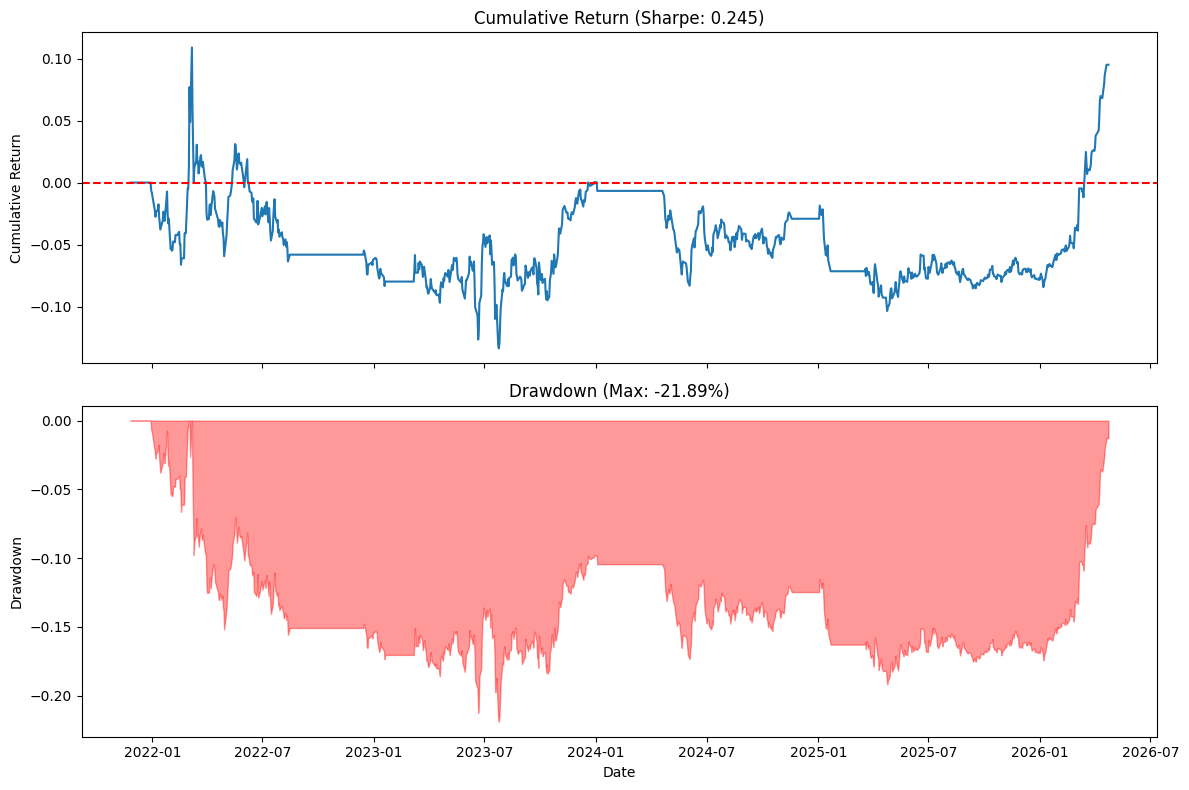

In [53]:
THRESHOLD = best_threshold

positions_final = np.zeros(len(z_scores_test))
position_final = 0
for i in range(len(z_scores_test)):
    if np.isnan(z_scores_test.iloc[i]):
        position_final = 0
    elif z_scores_test.iloc[i] >= THRESHOLD:
        position_final = -1
    elif z_scores_test.iloc[i] <= -THRESHOLD:
        position_final = 1
    elif position_final == 1 and z_scores_test.iloc[i] >= 0:
        position_final = 0
    elif position_final == -1 and z_scores_test.iloc[i] <= 0:
        position_final = 0
    positions_final[i] = position_final

split = int(len(df) * 0.7)
hedge_test = hedge_final[split:]
corn_test = df_test['Corn'].values
wheat_test = df_test['Wheat'].values
cotton_test = df_test['Cotton'].values
delta_corn = df_test['Corn'].diff().values
delta_wheat = df_test['Wheat'].diff().values
delta_cotton = df_test['Cotton'].diff().values

pnl_fixed = np.zeros(len(positions_final))
returns = np.zeros(len(positions_final))
hedge_entry = None
capital_entry = np.nan

for i in range(1, len(positions_final)):
    prev_pos = positions_final[i-1]
    curr_pos = positions_final[i]
    
    if prev_pos == 0 and curr_pos != 0:
        hedge_entry = hedge_test[i]
        capital_entry = (abs(hedge_entry[0]) * corn_test[i-1] +
                         abs(hedge_entry[1]) * wheat_test[i-1] +
                         abs(hedge_entry[2]) * cotton_test[i-1])
    
    if curr_pos != 0 and hedge_entry is not None:
        pnl_fixed[i] = curr_pos * (hedge_entry[0] * delta_corn[i] +
                                    hedge_entry[1] * delta_wheat[i] +
                                    hedge_entry[2] * delta_cotton[i])
        returns[i] = pnl_fixed[i] / capital_entry
    else:
        pnl_fixed[i] = 0.0
        returns[i] = 0.0
    
    if curr_pos == 0:
        hedge_entry = None
        capital_entry = np.nan

returns = pd.Series(returns, index=df_test.index)
pnl_fixed = pd.Series(pnl_fixed, index=df_test.index)

sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252) if np.std(returns) > 0 else 0
cum_ret = (1 + returns).cumprod() - 1
total_ret = cum_ret.iloc[-1]
rolling_max = (1 + returns).cumprod().cummax()
drawdown = (1 + returns).cumprod() / rolling_max - 1
max_dd = drawdown.min()

print(f'Sharpe Ratio:   {sharpe:.3f}')
print(f'Total Return:   {total_ret:.2%}')
print(f'Max Drawdown:   {max_dd:.2%}')
print(f'Total P&L:      {pnl_fixed.sum():.2f}')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(cum_ret.index, cum_ret.values)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'Cumulative Return (Sharpe: {sharpe:.3f})')
axes[0].set_ylabel('Cumulative Return')

axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.4, color='red')
axes[1].set_title(f'Drawdown (Max: {max_dd:.2%})')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()


### Combination 4: Soybean + Wheat + Cotton

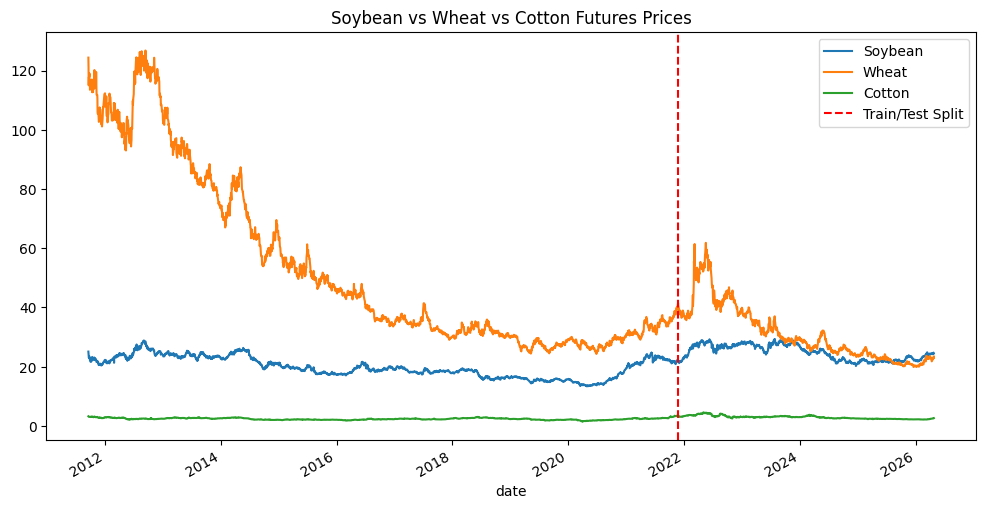

In [54]:
df1=pd.read_csv(r'C:\Users\zezar\TilburgUniversity\Spring2026-TIC\Ensemble_Wiktor\data\merged_corn_soybean_wheat_cotton.csv', skiprows=[1], index_col=0, parse_dates=True)
soybean=df1['close_soybean']
wheat=df1['close_wheat']
cotton=df1['close_cotton']


df=pd.concat([soybean, wheat, cotton], axis=1)
df.columns=['Soybean', 'Wheat', 'Cotton']

df_train=df.iloc[:int(len(df)*0.7)]
df_test=df.iloc[int(len(df)*0.7):]

plt.figure(figsize=(12, 6))

df['Soybean'].plot(label='Soybean')
df['Wheat'].plot(label='Wheat')
df['Cotton'].plot(label='Cotton')

plt.axvline(x=df_train.index[-1], color='red', linestyle='--', label='Train/Test Split')
plt.title('Soybean vs Wheat vs Cotton Futures Prices')
plt.legend()
plt.show()


In [55]:
adf_soybean=adfuller(df_train['Soybean'])
adf_wheat=adfuller(df_train['Wheat'])
adf_cotton=adfuller(df_train['Cotton'])

print(f'ADF Statistic for Soybean: {adf_soybean[0]}')
print(f'p-value for Soybean: {adf_soybean[1]}')
print(f'ADF Statistic for Wheat: {adf_wheat[0]}')
print(f'p-value for Wheat: {adf_wheat[1]}')
print(f'ADF Statistic for Cotton: {adf_cotton[0]}')
print(f'p-value for Cotton: {adf_cotton[1]}')
print(f'Critical Values: {adf_soybean[4]}')


ADF Statistic for Soybean: -1.8500507300892937
p-value for Soybean: 0.3559109696697546
ADF Statistic for Wheat: -2.2212542264301733
p-value for Wheat: 0.19862202636181386
ADF Statistic for Cotton: -2.301365976236572
p-value for Cotton: 0.17152779547395824
Critical Values: {'1%': -3.4329476085791493, '5%': -2.8626876136761292, '10%': -2.5673809185248175}


In [56]:
soybean_diff=df_train['Soybean'].diff().dropna()
adf_soybean_diff=adfuller(soybean_diff)

wheat_diff=df_train['Wheat'].diff().dropna()
adf_wheat_diff=adfuller(wheat_diff)

cotton_diff=df_train['Cotton'].diff().dropna()
adf_cotton_diff=adfuller(cotton_diff)

print(f'ADF Statistic for Soybean: {adf_soybean_diff[0]}')
print(f'p-value for Soybean: {adf_soybean_diff[1]}')
print(f'ADF Statistic for Wheat: {adf_wheat_diff[0]}')
print(f'p-value for Wheat: {adf_wheat_diff[1]}')
print(f'ADF Statistic for Cotton: {adf_cotton_diff[0]}')
print(f'p-value for Cotton: {adf_cotton_diff[1]}')
print(f'Critical Values: {adf_soybean_diff[4]}')


ADF Statistic for Soybean: -56.092950108524676
p-value for Soybean: 0.0
ADF Statistic for Wheat: -11.396413869426183
p-value for Wheat: 7.838538580427442e-21
ADF Statistic for Cotton: -51.93705238817174
p-value for Cotton: 0.0
Critical Values: {'1%': -3.4329476085791493, '5%': -2.8626876136761292, '10%': -2.5673809185248175}


In [57]:
result = coint_johansen(df_train, det_order=0, k_ar_diff=1)

print('Trace Statistics:')
print(result.lr1)
print('Critical values 90%, 95%, 99%:')
print(result.cvt)

print('\nEigen Statistics:')
print(result.lr2)
print('Critical values 90%, 95%, 99%:')
print(result.cvm)

print('\nEigenvalues:')
print(result.eig)

print('\nEigenvectors:')
print(result.evec)


Trace Statistics:
[23.8233582   8.64038893  3.24739714]
Critical values 90%, 95%, 99%:
[[27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]

Eigen Statistics:
[15.18296928  5.39299179  3.24739714]
Critical values 90%, 95%, 99%:
[[18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]

Eigenvalues:
[0.00600687 0.00213779 0.00128782]

Eigenvectors:
[[ 4.52341055e-01 -2.70782624e-01  7.88723368e-02]
 [-4.53931060e-02 -1.71566173e-03 -3.41856962e-02]
 [-2.41405026e+00 -2.20286968e-01  2.93162693e+00]]


In [58]:
hedge_ratios = result.evec[:, 0]
print(f'Soybean:    {hedge_ratios[0]:.4f}')
print(f'Wheat: {hedge_ratios[1]:.4f}')
print(f'Cotton:   {hedge_ratios[2]:.4f}')


Soybean:    0.4523
Wheat: -0.0454
Cotton:   -2.4141


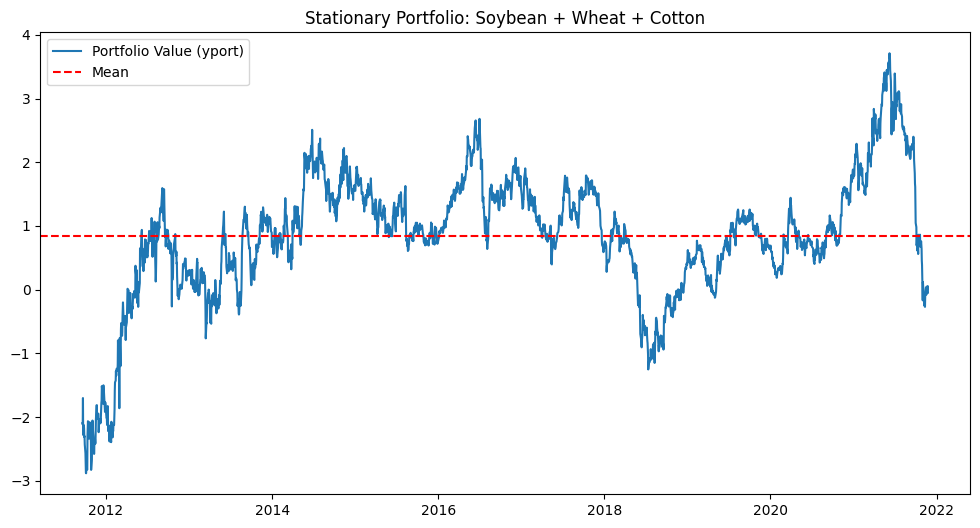


ADF Statistic: -3.5329
p-value: 0.0072
Critical Values: {'1%': -3.4329476085791493, '5%': -2.8626876136761292, '10%': -2.5673809185248175}


In [59]:
yport = (df_train * hedge_ratios).sum(axis=1)

plt.figure(figsize=(12, 6))
plt.plot(yport.index, yport.values, label='Portfolio Value (yport)')
plt.axhline(yport.mean(), color='red', linestyle='--', label='Mean')
plt.title('Stationary Portfolio: Soybean + Wheat + Cotton')
plt.legend()
plt.show()

adf_yport = adfuller(yport, maxlag=1, autolag=None)
print(f'\nADF Statistic: {adf_yport[0]:.4f}')
print(f'p-value: {adf_yport[1]:.4f}')
print(f'Critical Values: {adf_yport[4]}')


In [60]:
yport_diff = yport.diff().dropna()
yport_lagged = yport.shift(1).dropna()
yport_lagged = sm.add_constant(yport_lagged)
model_hl = sm.OLS(yport_diff, yport_lagged)
result_hl = model_hl.fit()
lambda_val = result_hl.params.iloc[1]
half_life = -np.log(2) / lambda_val
print(f'Half life: {half_life:.1f} days')


Half life: 74.4 days


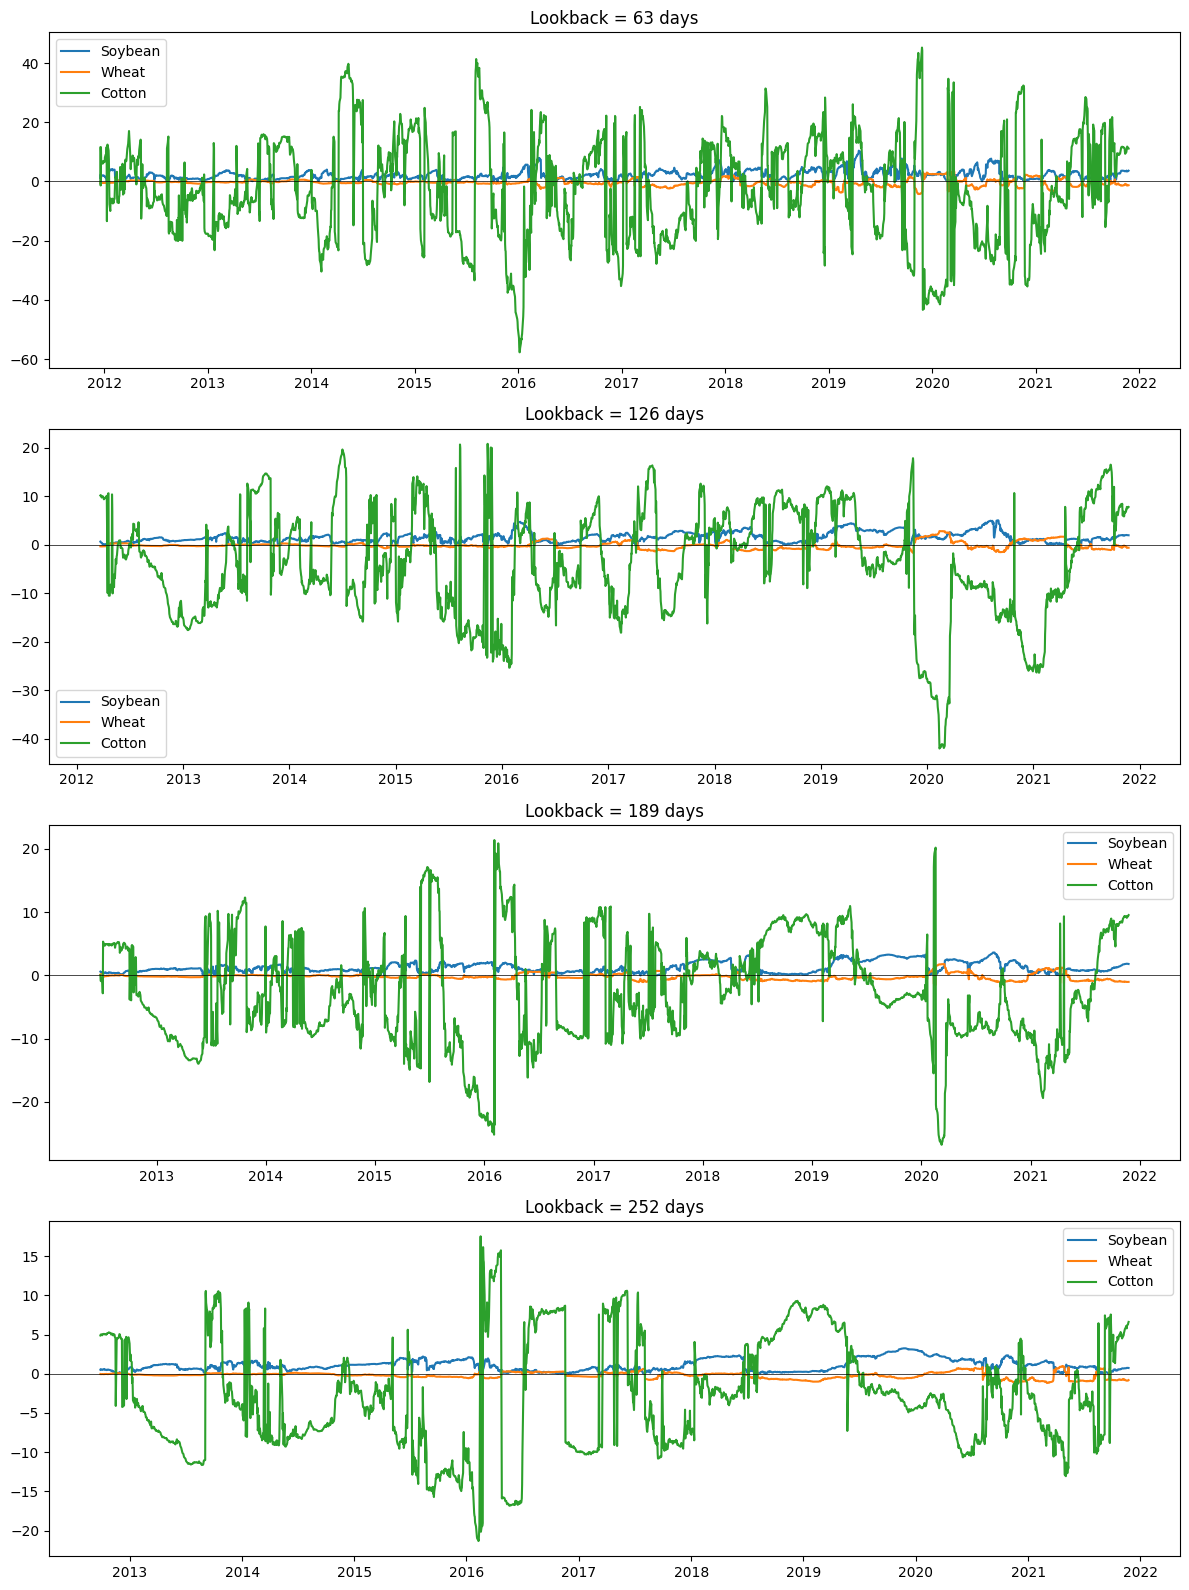

In [61]:
def rolling_eigenvectors(df_train, lookback):
    n_assets = df_train.shape[1]
    eigenvectors = np.full((len(df_train), n_assets), np.nan)
    
    for i in range(lookback, len(df_train)):
        window = df_train.iloc[i-lookback:i]
        try:
            result = coint_johansen(window, det_order=0, k_ar_diff=1)
            eigenvectors[i] = result.evec[:, 0]
        except:
            pass
    
    return pd.DataFrame(eigenvectors, index=df_train.index, columns=df_train.columns)

fig, axes = plt.subplots(4, 1, figsize=(12, 16))
for ax, lb in zip(axes, [63, 126, 189, 252]):
    eigvec = rolling_eigenvectors(df_train, lb)
    for col in eigvec.columns:
        ax.plot(eigvec.index, eigvec[col], label=col)
    ax.set_title(f'Lookback = {lb} days')
    ax.legend()
    ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


{1.0: 1.6339669910730288, 1.5: 1.0346848889040487, 2.0: 0.8881256205677821, 2.5: 0.7135055107827478, 3.0: 0.5717060549017879}
Best threshold: 1.0


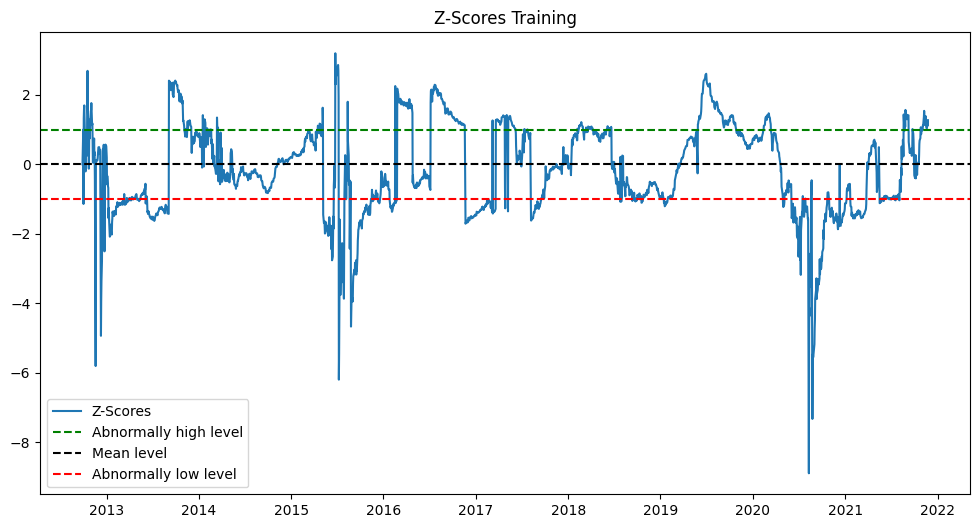

In [62]:
LOOKBACK = 252
hedge_train = np.full((len(df_train), 3), np.nan)
rolling_spread = np.full(len(df_train), np.nan)

for i in range(LOOKBACK, len(df_train)):
    window = df_train.iloc[i-LOOKBACK:i]
    result_window = coint_johansen(window, det_order=0, k_ar_diff=1)
    hedge_train[i] = result_window.evec[:, 0]
    rolling_spread[i] = (df_train.iloc[i].values * result_window.evec[:, 0]).sum()

rolling_spread_series = pd.Series(rolling_spread, index=df_train.index)

z_scores = np.full(len(rolling_spread_series), np.nan)
for i in range(LOOKBACK, len(rolling_spread_series)):
    window_rolling_spread = rolling_spread_series.iloc[i-LOOKBACK:i]
    mean_rolling_spread = np.mean(window_rolling_spread)
    std_rolling_spread = np.std(window_rolling_spread)
    if std_rolling_spread == 0:
        z_scores[i] = 0
    else:
        z_scores[i] = (window_rolling_spread.iloc[-1] - mean_rolling_spread) / std_rolling_spread

thresholds = [1.0, 1.5, 2.0, 2.5, 3.0]
results_opt = {}

for entry in thresholds:
    positions = np.zeros(len(z_scores))
    position = 0
    for j in range(len(z_scores)):
        if np.isnan(z_scores[j]):
            position = 0
        elif z_scores[j] >= entry:
            position = -1
        elif z_scores[j] <= -entry:
            position = 1
        elif position == 1 and z_scores[j] >= 0:
            position = 0
        elif position == -1 and z_scores[j] <= 0:
            position = 0
        positions[j] = position
    
    spread_changes = rolling_spread_series.diff()
    pnl = positions * spread_changes
    if np.std(pnl) > 0:
        sharpe_ratio = np.mean(pnl) / np.std(pnl) * np.sqrt(252)
    else:
        sharpe_ratio = 0
    results_opt[entry] = sharpe_ratio

best_threshold = max(results_opt, key=results_opt.get)
print(results_opt)
print(f'Best threshold: {best_threshold}')

plt.figure(figsize=(12,6))
plt.plot(df_train.index, z_scores, label='Z-Scores')
plt.axhline(y=best_threshold, color='green', linestyle='--', label='Abnormally high level')
plt.axhline(y=0, color='black', linestyle='--', label='Mean level')
plt.axhline(y=-best_threshold, color='red', linestyle='--', label='Abnormally low level')
plt.title('Z-Scores Training')
plt.legend()
plt.show()


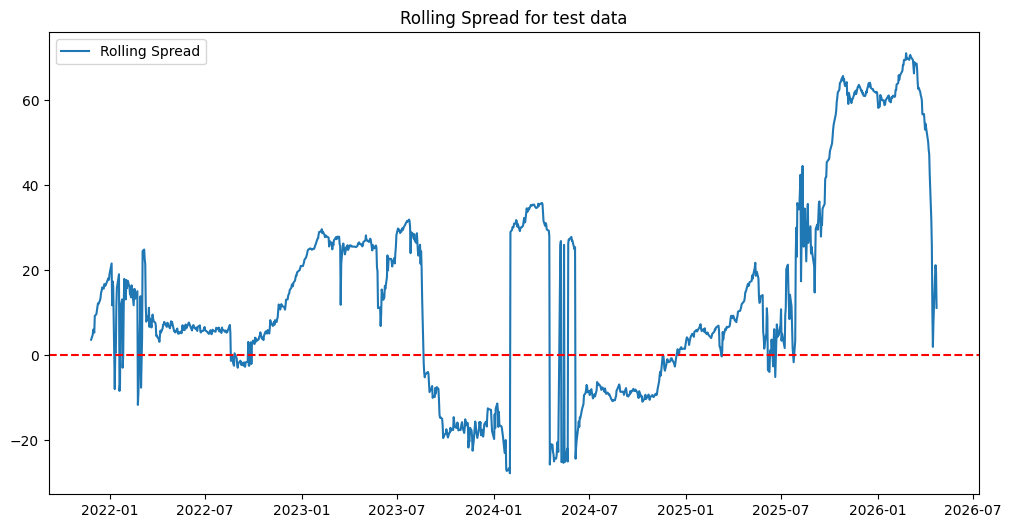

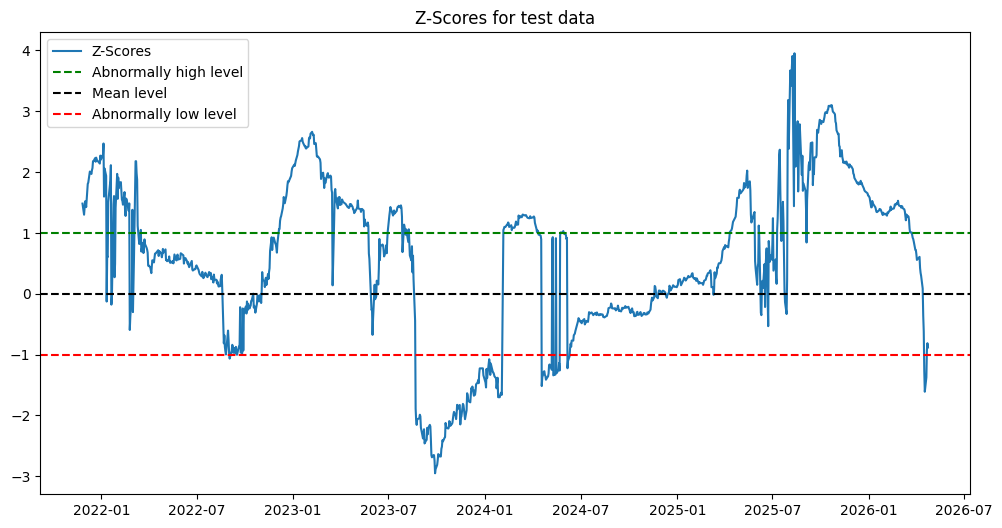

In [63]:
hedge_final = np.full((len(df), 3), np.nan)
spread_final = np.full(len(df), np.nan)

for i in range(LOOKBACK, len(df)):
    window = df.iloc[i-LOOKBACK:i]
    result_window = coint_johansen(window, det_order=0, k_ar_diff=1)
    hedge_final[i] = result_window.evec[:, 0]
    spread_final[i] = (df.iloc[i].values * result_window.evec[:, 0]).sum()

spread_final_series = pd.Series(spread_final, index=df.index)
hedge_final_df = pd.DataFrame(hedge_final, index=df.index, columns=['Soybean', 'Wheat', 'Cotton'])

z_scores_final = np.full(len(spread_final_series), np.nan)
for j in range(LOOKBACK, len(df)):
    window_spread_final = spread_final_series.iloc[j-LOOKBACK:j]
    mean_spread_final = np.mean(window_spread_final)
    std_spread_final = np.std(window_spread_final)
    if std_spread_final == 0:
        z_scores_final[j] = 0
    else:
        z_scores_final[j] = (window_spread_final.iloc[-1] - mean_spread_final) / std_spread_final

z_scores_final_series = pd.Series(z_scores_final, index=df.index)
z_scores_test = z_scores_final_series[df.index >= df_test.index[0]]
spread_test = spread_final_series[df.index >= df_test.index[0]]

plt.figure(figsize=(12,6))
plt.plot(df_test.index, spread_test, label='Rolling Spread')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Rolling Spread for test data')
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df_test.index, z_scores_test, label='Z-Scores')
plt.axhline(y=best_threshold, color='green', linestyle='--', label='Abnormally high level')
plt.axhline(y=0, color='black', linestyle='--', label='Mean level')
plt.axhline(y=-best_threshold, color='red', linestyle='--', label='Abnormally low level')
plt.title('Z-Scores for test data')
plt.legend()
plt.show()


Sharpe Ratio:   -0.167
Total Return:   -14.32%
Max Drawdown:   -32.37%
Total P&L:      -4.75


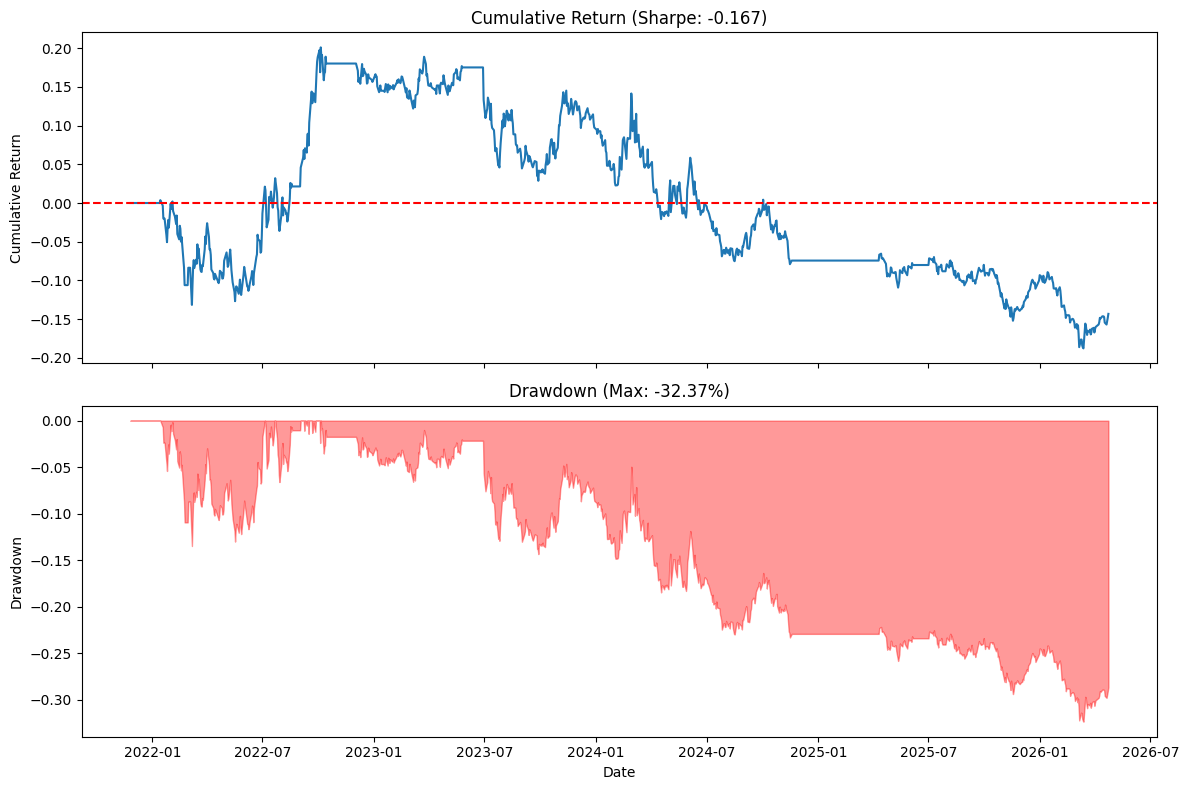

In [64]:
THRESHOLD = best_threshold

positions_final = np.zeros(len(z_scores_test))
position_final = 0
for i in range(len(z_scores_test)):
    if np.isnan(z_scores_test.iloc[i]):
        position_final = 0
    elif z_scores_test.iloc[i] >= THRESHOLD:
        position_final = -1
    elif z_scores_test.iloc[i] <= -THRESHOLD:
        position_final = 1
    elif position_final == 1 and z_scores_test.iloc[i] >= 0:
        position_final = 0
    elif position_final == -1 and z_scores_test.iloc[i] <= 0:
        position_final = 0
    positions_final[i] = position_final

split = int(len(df) * 0.7)
hedge_test = hedge_final[split:]
soybean_test = df_test['Soybean'].values
wheat_test = df_test['Wheat'].values
cotton_test = df_test['Cotton'].values
delta_soybean = df_test['Soybean'].diff().values
delta_wheat = df_test['Wheat'].diff().values
delta_cotton = df_test['Cotton'].diff().values

pnl_fixed = np.zeros(len(positions_final))
returns = np.zeros(len(positions_final))
hedge_entry = None
capital_entry = np.nan

for i in range(1, len(positions_final)):
    prev_pos = positions_final[i-1]
    curr_pos = positions_final[i]
    
    if prev_pos == 0 and curr_pos != 0:
        hedge_entry = hedge_test[i]
        capital_entry = (abs(hedge_entry[0]) * soybean_test[i-1] +
                         abs(hedge_entry[1]) * wheat_test[i-1] +
                         abs(hedge_entry[2]) * cotton_test[i-1])
    
    if curr_pos != 0 and hedge_entry is not None:
        pnl_fixed[i] = curr_pos * (hedge_entry[0] * delta_soybean[i] +
                                    hedge_entry[1] * delta_wheat[i] +
                                    hedge_entry[2] * delta_cotton[i])
        returns[i] = pnl_fixed[i] / capital_entry
    else:
        pnl_fixed[i] = 0.0
        returns[i] = 0.0
    
    if curr_pos == 0:
        hedge_entry = None
        capital_entry = np.nan

returns = pd.Series(returns, index=df_test.index)
pnl_fixed = pd.Series(pnl_fixed, index=df_test.index)

sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252) if np.std(returns) > 0 else 0
cum_ret = (1 + returns).cumprod() - 1
total_ret = cum_ret.iloc[-1]
rolling_max = (1 + returns).cumprod().cummax()
drawdown = (1 + returns).cumprod() / rolling_max - 1
max_dd = drawdown.min()

print(f'Sharpe Ratio:   {sharpe:.3f}')
print(f'Total Return:   {total_ret:.2%}')
print(f'Max Drawdown:   {max_dd:.2%}')
print(f'Total P&L:      {pnl_fixed.sum():.2f}')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(cum_ret.index, cum_ret.values)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'Cumulative Return (Sharpe: {sharpe:.3f})')
axes[0].set_ylabel('Cumulative Return')

axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.4, color='red')
axes[1].set_title(f'Drawdown (Max: {max_dd:.2%})')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()
